## **Crime Incidents Data Cleanning**

## Load Lib & Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("crime_incidents_cleaned2.csv")


## Explore Data

In [2]:
df.head()

,incident_id,crime_type,district,city,state,address,latitude,longitude,incident_datetime,officer_id,...,num_arrests,property_loss_usd,reported_online,incident_time,incident_hour,incident_year,incident_month,incident_day,incident_dow,crime_cluster
0,Inc001115,Assault,South,Maplewood,Ga,2830 Cedar Lane,NaN,-77.500710,2024-04-16 08:45:03,Off0078,...,0,24725.40,True,08:45:03,8,2024,4,16,Tuesday,NaN
1,Inc004706,Burglary,Southeast,Maplewood,Oh,2361 Park Rd,29.422717,-77.167016,2022-01-11 22:03:29,Off0059,...,2,44839.49,True,22:03:29,22,2022,1,11,Tuesday,2.0
2,Inc002249,Homicide,Southwest,Lakewood,Az,1067 Main St,39.411460,-98.615298,2022-04-14 11:39:24,Off0088,...,2,15963.38,True,11:39:24,11,2022,4,14,Thursday,0.0
3,Inc000021,Property Damage,Central,Springfield,Az,4713 Washington Ave,28.633439,-99.030051,2020-12-09 15:14:24,Off0077,...,5,48680.14,False,15:14:24,15,2020,12,9,Wednesday,2.0
4,Inc000488,Domestic Violence,North,Lakewood,Pa,1371 River Rd,34.217850,-121.614731,2021-07-24 20:08:13,Off0083,...,2,23513.01,True,20:08:13,20,2021,7,24,Saturday,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         5050 non-null   object 
 1   crime_type          5050 non-null   object 
 2   district            5050 non-null   object 
 3   city                5050 non-null   object 
 4   state               5050 non-null   object 
 5   address             5050 non-null   object 
 6   latitude            4623 non-null   float64
 7   longitude           4576 non-null   float64
 8   incident_datetime   5050 non-null   object 
 9   officer_id          5050 non-null   object 
 10  officer_first_name  5050 non-null   object 
 11  officer_last_name   5050 non-null   object 
 12  badge_number        5050 non-null   object 
 13  suspect_id          5050 non-null   object 
 14  suspect_first_name  5050 non-null   object 
 15  suspect_last_name   5050 non-null   object 
 16  suspec

### Missing Values

<Axes: >

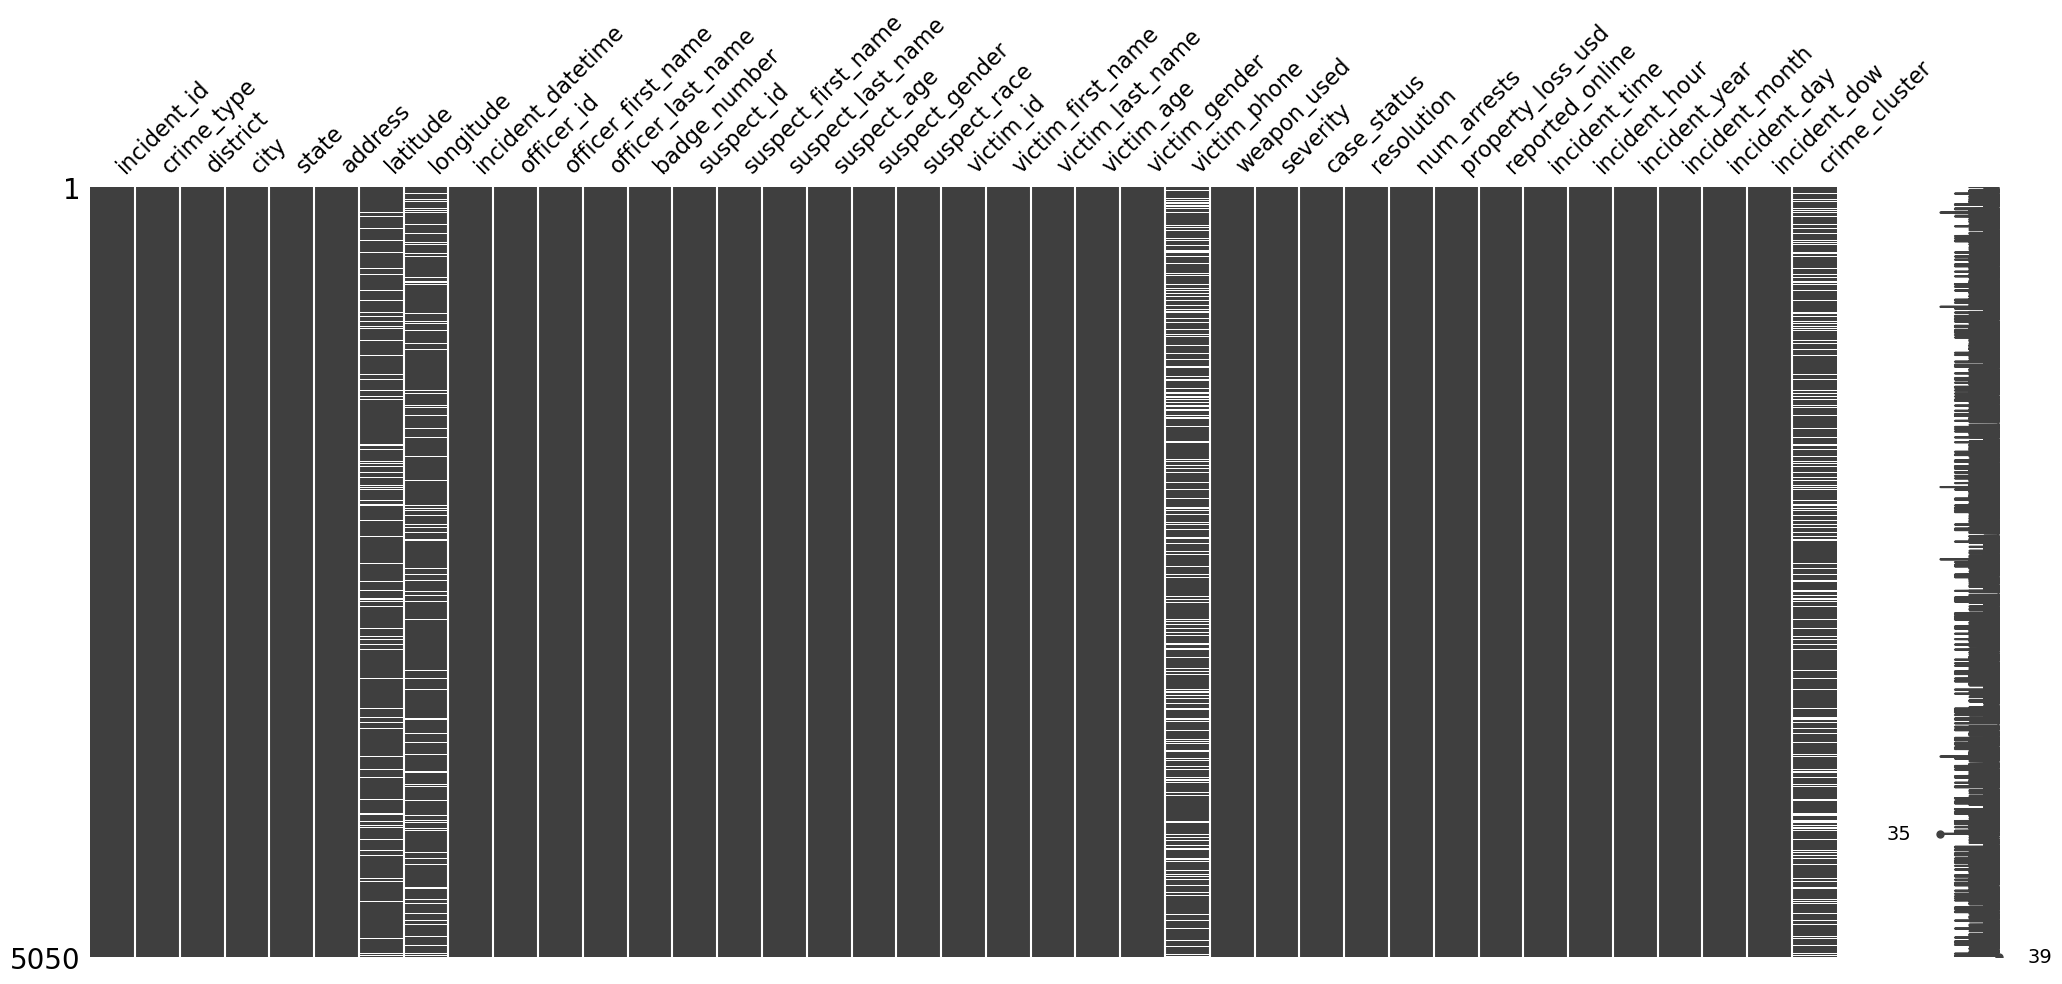

In [4]:
#  Load The Lib

import missingno as msno
msno.matrix(df)

* No Missing In >> incident_id	| crime_type	| district |	city	| state	address | officer Id + 1st Name + Lanst Name

## Handel Duplicates

In [5]:
# Duplicates in Pk Column >> incident_id
df['incident_id'].duplicated().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(subset='incident_id', inplace=True)
df['incident_id'].duplicated().sum()

np.int64(0)

## Data Type & Formating For **Categorical Columns**


#### Standardization for **All Categorical Columns**

In [8]:
sorted(df["crime_type"].unique())

['Abduction',
 'Armed Robbery',
 'Arson',
 'Assault',
 'Battery',
 'Breaking & Entering',
 'Burglary',
 'Cybercrime',
 'DUI',
 'Deception',
 'Domestic Violence',
 'Drug Offense',
 'Fire Setting',
 'Fraud',
 'Graffiti',
 'Hacking',
 'Homicide',
 'Kidnapping',
 'Larceny',
 'Manslaughter',
 'Murder',
 'Narcotics',
 'Online Fraud',
 'Property Damage',
 'Robbery',
 'Scam',
 'Sexual Assault',
 'Stealing',
 'Theft',
 'Trespassing',
 'Vandalism']

In [9]:
df[df["crime_type"].str.lower() == "theft"]["crime_type"].value_counts()

crime_type
Theft    209
Name: count, dtype: int64

In [10]:
# No. Unique in Crime Type
df['crime_type'].nunique()

31

**Handel All Categorical/Object Formating with 1 Fun**

In [11]:
cat_cols = df.select_dtypes("object").columns
df[cat_cols] = df[cat_cols].apply(
    lambda x: x.str.strip().str.replace(r"\s+", " ", regex=True).str.lower().str.title()
)

In [12]:
df[df["crime_type"].str.lower() == "theft"]["crime_type"].value_counts()

crime_type
Theft    209
Name: count, dtype: int64

#### Standardization for **Crime Type** Column

In [13]:
# No. Unique in Crime Type
df['crime_type'].nunique()

31

In [14]:
# Is there any Aliases
sorted(df["crime_type"].unique())

['Abduction',
 'Armed Robbery',
 'Arson',
 'Assault',
 'Battery',
 'Breaking & Entering',
 'Burglary',
 'Cybercrime',
 'Deception',
 'Domestic Violence',
 'Drug Offense',
 'Dui',
 'Fire Setting',
 'Fraud',
 'Graffiti',
 'Hacking',
 'Homicide',
 'Kidnapping',
 'Larceny',
 'Manslaughter',
 'Murder',
 'Narcotics',
 'Online Fraud',
 'Property Damage',
 'Robbery',
 'Scam',
 'Sexual Assault',
 'Stealing',
 'Theft',
 'Trespassing',
 'Vandalism']

In [15]:
# No. Unique in Crime Type Before Mapping
df['crime_type'].nunique()

31

Fuzzy Matching for Crime Type

In [169]:
from thefuzz import process

standard_crimes = [
    "Assault", "Armed Robbery", "Arson", "Battery", "Breaking & Entering", 
    "Burglary", "Cybercrime", "Deception", "Domestic Violence", "Drug Offense", 
    "DUI", "Fire Setting", "Fraud", "Graffiti", "Hacking", "Homicide", 
    "Kidnapping", "Larceny", "Manslaughter", "Murder", "Narcotics", 
    "Online Fraud", "Property Damage", "Robbery", "Scam", "Sexual Assault", 
    "Stealing", "Theft", "Trespassing", "Vandalism", "Abduction"
]

def fuzzy_match_crime(val, choices=standard_crimes, threshold=80):
    if not isinstance(val, str) or pd.isna(val):
        return val
    match, score = process.extractOne(val, choices)
    return match if score >= threshold else val

df["crime_type"] = df["crime_type"].apply(fuzzy_match_crime)
df["crime_type"].nunique()

31

In [17]:
# Is there any Aliases
sorted(df["crime_type"].unique())

['Abduction',
 'Armed Robbery',
 'Arson',
 'Assault',
 'Battery',
 'Breaking & Entering',
 'Burglary',
 'Cybercrime',
 'DUI',
 'Deception',
 'Domestic Violence',
 'Drug Offense',
 'Fire Setting',
 'Fraud',
 'Graffiti',
 'Hacking',
 'Homicide',
 'Kidnapping',
 'Larceny',
 'Manslaughter',
 'Murder',
 'Narcotics',
 'Online Fraud',
 'Property Damage',
 'Robbery',
 'Scam',
 'Sexual Assault',
 'Stealing',
 'Theft',
 'Trespassing',
 'Vandalism']

In [18]:
# No. Unique in Crime Type after Mapping
df['crime_type'].nunique()

31

#### Standardization for **District** Column

In [19]:
# No. Unique in district befor Mapping
df['district'].nunique()

10

In [20]:
# Is there any Aliases
sorted(df["district"].unique())

['Central',
 'East',
 'Midtown',
 'North',
 'Northeast',
 'Northwest',
 'South',
 'Southeast',
 'Southwest',
 'West']

###  District Name Standardization (Fuzzy Matching)

In [168]:
from thefuzz import process

standard_districts = [
    "Central",
    "East",
    "Midtown",
    "North",
    "Northeast",
    "Northwest",
    "South",
    "Southeast",
    "Southwest",
    "West",
]


def fuzzy_match_district(val, choices=standard_districts, threshold=80):
  if not isinstance(val, str) or pd.isna(val):
    return val
  match, score = process.extractOne(val, choices)
  return match if score >= threshold else val


df["district"] = df["district"].apply(fuzzy_match_district)
df["district"].nunique()

10

In [22]:
# Is there any Aliases
sorted(df["district"].unique())

['Central',
 'East',
 'Midtown',
 'North',
 'Northeast',
 'Northwest',
 'South',
 'Southeast',
 'Southwest',
 'West']

In [23]:
# No. Unique in district after Mapping
df['district'].nunique()

10

#### Standardization for **City** Column

In [24]:
# No. Unique in city befor Mapping
df['city'].nunique()

8

In [25]:
# Is there any Aliases
sorted(df["city"].unique())

['Centerville',
 'Fairview',
 'Hillcrest',
 'Lakewood',
 'Maplewood',
 'Oakdale',
 'Riverside',
 'Springfield']

#### Standardization for **State** Column

In [26]:
# No. Unique in city
df['city'].nunique()

8

In [27]:
# Is there any Aliases
sorted(df["city"].unique())

['Centerville',
 'Fairview',
 'Hillcrest',
 'Lakewood',
 'Maplewood',
 'Oakdale',
 'Riverside',
 'Springfield']

#### Standardization for **Address** Column

In [28]:
# No. Unique in city
df['address'].nunique()

4895

In [29]:
# Is there any Aliases
# sorted(df["address"].unique())

In [30]:
df['address'].isna().sum()

np.int64(0)

#### Standardization for **Officer Id | officer first name | officer last name| Badge number** Column

In [31]:
# No. Unique in city
df['officer_id'].nunique()

150

In [32]:
df['officer_id'].isnull().sum()

np.int64(0)

<Axes: >

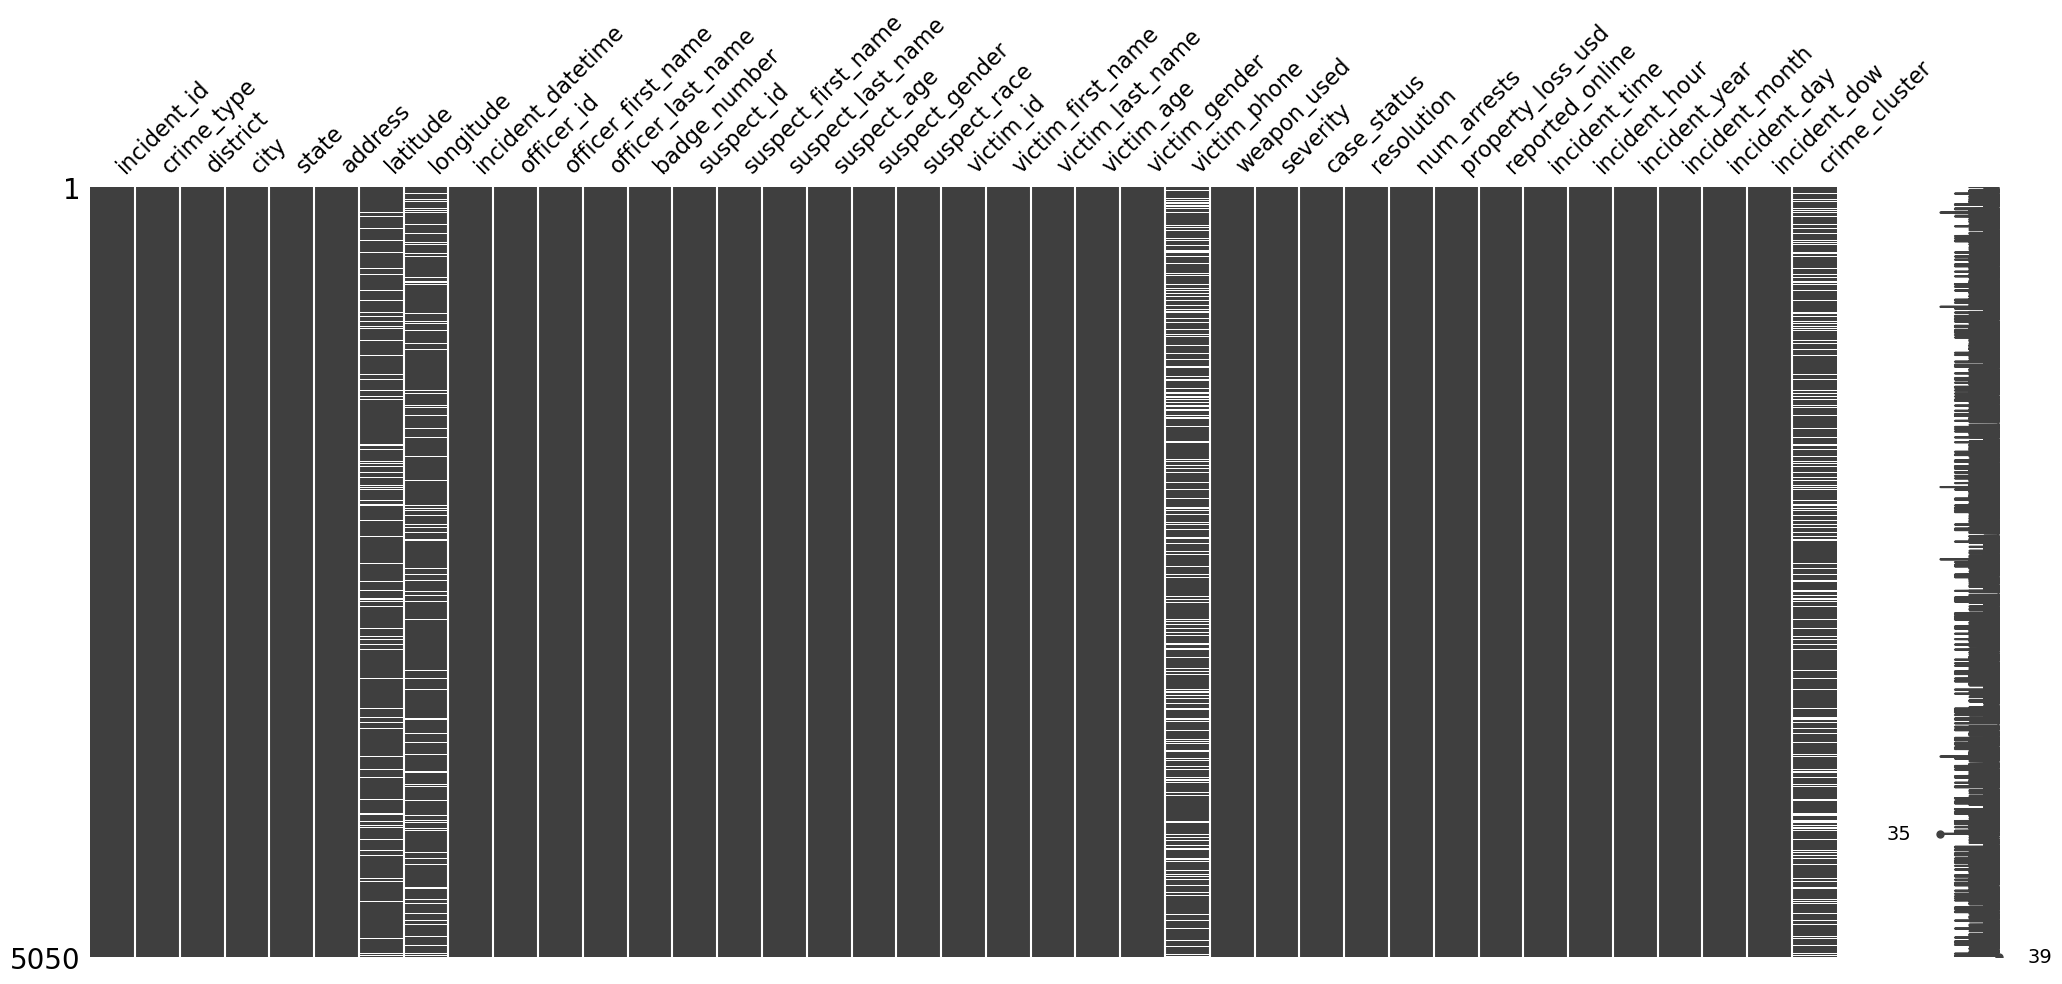

In [33]:
msno.matrix(df)

#### Standardization for **suspect id** Column

In [34]:
df['suspect_id'].isnull().sum()

np.int64(0)

In [35]:
df['suspect_id'] = df['suspect_id'].fillna("Unknown")

In [36]:
df['suspect_id'].isnull().sum()

np.int64(0)

#### Standardization for **suspect first name** Column

In [37]:
df['suspect_first_name'].isnull().sum()

np.int64(0)

In [38]:
df['suspect_first_name'] = df['suspect_first_name'].fillna("Unknown")

In [39]:
df['suspect_first_name'].isnull().sum()

np.int64(0)

#### Standardization for **suspect last name** Column

In [40]:
df['suspect_last_name'].isnull().sum()

np.int64(0)

In [41]:
df['suspect_last_name'] = df['suspect_last_name'].fillna("Unknown")

In [42]:
df['suspect_first_name'].isnull().sum()

np.int64(0)

#### Standardization for **suspect gender** Column

In [43]:
# No. Unique in district befor Mapping
df['suspect_gender'].nunique()

3

In [44]:
# Is there any Aliases
sorted(df["suspect_gender"].dropna().unique())

['Female', 'Male', 'Other']

In [45]:
df["suspect_gender"].isnull().sum()

np.int64(0)

In [46]:
df["suspect_gender"].value_counts()

suspect_gender
Female    2580
Male      2157
Other      313
Name: count, dtype: int64

In [47]:
gender_mapping = {
    "F": "Female",
    "M": "Male",
    "Unknow":"Unknown"
}

df["suspect_gender"] = df["suspect_gender"].replace(gender_mapping)
df["suspect_gender"] = df["suspect_gender"].fillna("Unknown")

In [48]:
# df["suspect_gender"].unique()
df["suspect_gender"].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [49]:
df["suspect_gender"].isnull().sum()

np.int64(0)

In [50]:
df["suspect_gender"].value_counts()

suspect_gender
Female    2580
Male      2157
Other      313
Name: count, dtype: int64

#### Standardization for **suspect race** Column

In [51]:
# No. Unique in district befor Mapping
df['suspect_race'].nunique()

6

In [52]:
df["suspect_race"] = df["suspect_race"].fillna("Unknown")

In [53]:
# Is there any Aliases
df["suspect_race"].unique()

array(['Asian', 'Black', 'White', 'Unknown', 'Hispanic', 'Other'],
      dtype=object)

In [54]:
df['suspect_race'].isnull().sum()

np.int64(0)

#### Standardization for **'victim_id', 'victim_first_name', 'victim_last_name', 'victim_gender', 'weapon_used'** Column

In [55]:
cols = ['victim_id', 'victim_first_name', 'victim_last_name', 'victim_gender', 'weapon_used']

df[cols].isna().sum()

victim_id            0
victim_first_name    0
victim_last_name     0
victim_gender        0
weapon_used          0
dtype: int64

In [56]:
df["victim_gender"].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [57]:
mapping = {
    'M': 'Male',
    'F': 'Female',
    'M': 'Male',
    'F': 'Female',
    'Other': 'Other',
    'Unknown': 'Unknown'
}

df['victim_gender'] = df['victim_gender'].replace(mapping)

In [58]:
df["victim_gender"].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [59]:
cols = ['victim_id', 'victim_first_name', 'victim_last_name', 'victim_gender', 'weapon_used', 'case_status', 'resolution']

df[cols] = df[cols].fillna("Unknown")
df[cols].isna().sum()

victim_id            0
victim_first_name    0
victim_last_name     0
victim_gender        0
weapon_used          0
case_status          0
resolution           0
dtype: int64

In [60]:
df["victim_gender"].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [61]:
sorted(df['case_status'].dropna().unique())

['Closed', 'Investgation', 'Open', 'Pending', 'Resolved']

In [62]:
mapping = {
    'Pendng': 'Pending',
    'Under Investigation':'Investgation'
}

df['case_status'] = df['case_status'].replace(mapping)

In [63]:
sorted(df['case_status'].dropna().unique())

['Closed', 'Investgation', 'Open', 'Pending', 'Resolved']

In [64]:
sorted(df['resolution'].dropna().unique())

['Arrest Made', 'Dismissed', 'No Arrest', 'Warning Issued']

In [65]:
resolution_mapping = {
    "Arres Made": "Arrest Made",
    "Arrest Made": "Arrest Made",
    "Case Dismissed": "Dismissed",
    "Dismissed": "Dismissed",
    "No Arrest": "No Arrest",
    "Unknown": "Unknown",
    "Warning": "Warning Issued",
    "Warning Issued": "Warning Issued"
}

df["resolution"] = df["resolution"].map(resolution_mapping)

In [66]:
sorted(df['resolution'].dropna().unique())

['Arrest Made', 'Dismissed', 'No Arrest', 'Warning Issued']

#### Standardization for **reported_online** Column | **boolean column**

In [67]:
df["reported_online"].unique()

array(['True', 'False', 'Unknown'], dtype=object)

In [68]:
df["reported_online"] = df["reported_online"].replace({
    "True": True, "Yes": True, "1": True,
    "False": False, "No": False, "0": False
}).fillna("Unknown")

In [69]:
df["reported_online"].unique()

array([True, False, 'Unknown'], dtype=object)

In [70]:
df["reported_online"].isnull().sum()

np.int64(0)

#### Standardization for **vivtim_phone** Column

In [71]:
df['victim_phone'].describe()

count    4.031000e+03
mean     5.928388e+11
std      2.301913e+11
min      2.004055e+11
25%      3.880506e+11
50%      5.999465e+11
75%      7.886248e+11
max      9.998257e+11
Name: victim_phone, dtype: float64

In [72]:
df['victim_phone'].head(10)

0    6.223266e+11
1    2.419735e+11
2    2.445848e+11
3    5.021227e+11
4    9.698767e+11
5    5.903326e+11
6    4.315796e+11
7    5.875052e+11
8    3.956213e+11
9    3.764403e+11
Name: victim_phone, dtype: float64

In [73]:
clean_phone = df["victim_phone"].astype(str).str.replace(r"\D", "", regex=True)
df["victim_phone"] = pd.to_numeric(clean_phone, errors="coerce").astype("Int64")

In [74]:
df['victim_phone'].head(10)

0    6223265920000
1    2419734826000
2    2445847696000
3    5021227484000
4    9698766873000
5    5903326488000
6    4315796170000
7    5875051798000
8    3956212676000
9    3764403132000
Name: victim_phone, dtype: Int64

#### Standardization for **severity** Column

In [75]:
df["severity"].unique()

array(['Medium', 'High', 'Low', 'Critical'], dtype=object)

In [76]:
df["severity"].isnull().sum()

np.int64(0)

In [77]:
severity_map = {
    '1': 'Low',
    '2': 'Medium',
    '3': 'High',
    '4': 'critical',
    'med': 'Medium',
    'Med': 'Medium',
    'medium': 'Medium',
    'low': 'Low',
    'high': 'High',
    'Medium': 'Medium',
    'crit': 'Critical',
    'Crit': 'Critical',
    'criticl': 'Critical',
    'critical': 'Critical'
}

df['severity'] = df['severity'].replace(severity_map).fillna('Unknown')
df['severity'].unique()

array(['Medium', 'High', 'Low', 'Critical'], dtype=object)

In [78]:
df["severity"].isnull().sum()

np.int64(0)

### Drop Column **Notes**

In [79]:
df.drop(columns="notes", inplace=True, errors="ignore")

## Group By


#### Group By for r **victim_gender** 

In [80]:
df["victim_gender"].value_counts()

victim_gender
Male      2337
Female    2328
Other      385
Name: count, dtype: int64

In [81]:
gender_mode = (df[df["victim_gender"] != "Unknown"].groupby(["crime_type","district"])["victim_gender"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
gender_mode2 = (df[df["victim_gender"]!= "Unknown" ].groupby("crime_type")["victim_gender"]
    .agg(lambda x:x.mode().iloc[0] if not x.mode().empty else "UnKnown")          
    
)
mask =df["victim_gender"] == "Unknown"
df.loc[mask,"victim_gender"] = (df.loc[mask, ["crime_type", "district"]].apply(tuple , axis=1).map(gender_mode) 
    .fillna( df.loc[mask, "crime_type"].map(gender_mode2) ).fillna("Unknown"))
df["victim_gender"] = df["victim_gender"].fillna("Unknown")


In [82]:
df["victim_gender"].value_counts()

victim_gender
Male      2337
Female    2328
Other      385
Name: count, dtype: int64

#### Group By for **suspect gender** 

In [83]:
df["suspect_gender"].value_counts()

suspect_gender
Female    2580
Male      2157
Other      313
Name: count, dtype: int64

In [84]:
gender_mode_sus = (df[df["suspect_gender"] != "Unknown"].groupby(["crime_type","district"])["suspect_gender"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
gender_mode2_sus = (df[df["suspect_gender"]!= "Unknown" ].groupby("crime_type")["suspect_gender"]
    .agg(lambda x:x.mode().iloc[0] if not x.mode().empty else "UnKnown")          
    
)
mask =df["suspect_gender"] == "Unknown"
df.loc[mask,"suspect_gender"] = (df.loc[mask, ["crime_type", "district"]].apply(tuple , axis=1).map(gender_mode_sus) 
    .fillna( df.loc[mask, "crime_type"].map(gender_mode2_sus) ).fillna("Unknown"))
df["suspect_gender"] = df["suspect_gender"].fillna("Unknown")



In [85]:
df["suspect_gender"].value_counts()

suspect_gender
Female    2580
Male      2157
Other      313
Name: count, dtype: int64

#### Group By for **severity** 

In [86]:
df["severity"].value_counts()

severity
Medium      1691
Critical    1337
Low         1032
High         990
Name: count, dtype: int64

In [87]:
severity_mode = (
    df[df["severity"] != "Unknown"]
    .groupby("district")["severity"]
    .agg(lambda x: x.mode().iloc[0])
)
mask = df["severity"] == "Unknown"

df.loc[mask, "severity"] = (
    df.loc[mask, "district"].map(severity_mode)
)

In [88]:
df["severity"].value_counts()

severity
Medium      1691
Critical    1337
Low         1032
High         990
Name: count, dtype: int64

#### Group By for **weapon used** 

In [89]:
df["weapon_used"].value_counts()

weapon_used
Blunt Object    917
Knife           859
Firearm         805
Hands/Feet      378
Unarmed         369
Rifle           365
Bat             354
Hands           348
Gun             339
Pistol          316
Name: count, dtype: int64

In [90]:
weapon_mode = (df[df["weapon_used"] != "Unknown"].groupby(["crime_type","district"])["weapon_used"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
weapon_mode2 = (df[df["weapon_used"]!= "Unknown" ].groupby("crime_type")["weapon_used"]
    .agg(lambda x:x.mode().iloc[0] if not x.mode().empty else "UnKnown")          
    
)
mask =df["weapon_used"] == "Unknown"
df.loc[mask,"weapon_used"] = (df.loc[mask, ["crime_type", "district"]].apply(tuple , axis=1).map(weapon_mode) 
    .fillna( df.loc[mask, "crime_type"].map(weapon_mode2) ).fillna("Unknown"))
df["weapon_used"] = df["weapon_used"].fillna("Unknown")



In [91]:
df["weapon_used"].value_counts()

weapon_used
Blunt Object    917
Knife           859
Firearm         805
Hands/Feet      378
Unarmed         369
Rifle           365
Bat             354
Hands           348
Gun             339
Pistol          316
Name: count, dtype: int64

#### Group By for r **case_status** 

In [92]:
df["case_status"].value_counts()

case_status
Closed          1382
Investgation    1291
Open            1252
Pending          747
Resolved         378
Name: count, dtype: int64

In [93]:
case_status_mode = (df[df["case_status"] != "Unknown"].groupby(["crime_type","district"])["case_status"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
case_status_mode2 = (df[df["case_status"]!= "Unknown" ].groupby("crime_type")["case_status"]
    .agg(lambda x:x.mode().iloc[0] if not x.mode().empty else "UnKnown")          
    
)
mask =df["case_status"] == "Unknown"
df.loc[mask,"case_status"] = (df.loc[mask, ["crime_type", "district"]].apply(tuple , axis=1).map(case_status_mode) 
    .fillna( df.loc[mask, "crime_type"].map(case_status_mode2) ).fillna("Unknown"))
df["case_status"] = df["case_status"].fillna("Unknown")



In [94]:
df["case_status"].value_counts()

case_status
Closed          1382
Investgation    1291
Open            1252
Pending          747
Resolved         378
Name: count, dtype: int64

#### Group By for  **resolution** 

In [95]:
df["resolution"].value_counts()

resolution
Arrest Made       2243
Warning Issued     977
Dismissed          918
No Arrest          912
Name: count, dtype: int64

In [96]:
resolution_mode = (df[df["resolution"] != "Unknown"].groupby(["crime_type","case_status"])["resolution"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
resolution_mode2 = (df[df["resolution"]!= "Unknown" ].groupby("crime_type")["resolution"]
    .agg(lambda x:x.mode().iloc[0] if not x.mode().empty else "UnKnown")          
    
)
mask =df["resolution"] == "Unknown"
df.loc[mask,"resolution"] = (df.loc[mask, ["crime_type", "district"]].apply(tuple , axis=1).map(resolution_mode) 
    .fillna( df.loc[mask, "crime_type"].map(resolution_mode2) ).fillna("Unknown"))
df["resolution"] = df["resolution"].fillna("Unknown")



In [97]:
df["resolution"].value_counts()

resolution
Arrest Made       2243
Warning Issued     977
Dismissed          918
No Arrest          912
Name: count, dtype: int64

## Data Type & Formating For **Numeric Columns**


#### Standardization for **Latitude | Lognitude** Column

In [98]:
# df["latitude"] = df["latitude"].where(df["latitude"].between(-90, 90))
df["latitude"] = df["latitude"].where(df["latitude"].between(24, 49))

In [99]:
df["latitude"].isnull().sum()

np.int64(427)

In [100]:
df["longitude"].isnull().sum()

np.int64(474)

In [101]:
# df["longitude"] = df["longitude"].where(df["longitude"].between(-180, 180))
df["longitude"] = df["longitude"].where(df["longitude"].between(-125, -67))

In [102]:
df["longitude"].isnull().sum()

np.int64(474)

#### Standardization for **incident_datetime** Column




In [103]:
df["incident_datetime"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 5050 entries, 0 to 5049
Series name: incident_datetime
Non-Null Count  Dtype 
--------------  ----- 
5050 non-null   object
dtypes: object(1)
memory usage: 39.6+ KB


In [104]:
df["incident_datetime"].head(20)


0     2024-04-16 08:45:03
1     2022-01-11 22:03:29
2     2022-04-14 11:39:24
3     2020-12-09 15:14:24
4     2021-07-24 20:08:13
5     2020-05-03 00:00:00
6     2021-10-03 05:17:02
7     2023-09-30 14:49:01
8     2021-01-22 02:37:24
9     2021-03-29 04:16:18
10    2020-03-03 06:46:12
11    2018-09-09 02:11:36
12    2020-07-04 13:31:15
13    2023-07-30 09:05:34
14    2020-04-01 03:09:00
15    2020-11-26 07:15:19
16    2021-11-05 17:21:18
17    2022-10-07 17:15:25
18    2024-11-23 19:30:48
19    2018-08-26 04:50:54
Name: incident_datetime, dtype: object

In [105]:
# incident_datetime.to.datetime
df['incident_datetime']= pd.to_datetime(df['incident_datetime'],format='mixed')
df["incident_datetime"].info()
df['incident_datetime'].head(20)

<class 'pandas.core.series.Series'>
RangeIndex: 5050 entries, 0 to 5049
Series name: incident_datetime
Non-Null Count  Dtype         
--------------  -----         
5050 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 39.6 KB


0    2024-04-16 08:45:03
1    2022-01-11 22:03:29
2    2022-04-14 11:39:24
3    2020-12-09 15:14:24
4    2021-07-24 20:08:13
5    2020-05-03 00:00:00
6    2021-10-03 05:17:02
7    2023-09-30 14:49:01
8    2021-01-22 02:37:24
9    2021-03-29 04:16:18
10   2020-03-03 06:46:12
11   2018-09-09 02:11:36
12   2020-07-04 13:31:15
13   2023-07-30 09:05:34
14   2020-04-01 03:09:00
15   2020-11-26 07:15:19
16   2021-11-05 17:21:18
17   2022-10-07 17:15:25
18   2024-11-23 19:30:48
19   2018-08-26 04:50:54
Name: incident_datetime, dtype: datetime64[ns]

In [106]:
df["incident_datetime"].isnull().sum()

np.int64(0)

In [107]:
df['incident_datetime'] = df['incident_datetime'].ffill()

In [108]:
df["incident_datetime"].isnull().sum()

np.int64(0)

In [109]:
df["incident_time"] = df["incident_datetime"].dt.strftime("%H:%M:%S")
df["incident_hour"] = df["incident_datetime"].dt.hour
df["incident_year"] = df["incident_datetime"].dt.year
df["incident_month"] = df["incident_datetime"].dt.month
df["incident_day"] = df["incident_datetime"].dt.day

In [110]:
df[["incident_time","incident_hour", "incident_month", "incident_year", "incident_day"]].head()

,incident_time,incident_hour,incident_month,incident_year,incident_day
0,08:45:03,8,4,2024,16
1,22:03:29,22,1,2022,11
2,11:39:24,11,4,2022,14
3,15:14:24,15,12,2020,9
4,20:08:13,20,7,2021,24


#### Standardization for **badge_number** Column




In [111]:
df["badge_number"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 5050 entries, 0 to 5049
Series name: badge_number
Non-Null Count  Dtype 
--------------  ----- 
5050 non-null   object
dtypes: object(1)
memory usage: 39.6+ KB


In [112]:
result = df.groupby("officer_id")["badge_number"].nunique()

print(result.head(20))

officer_id
Off0001    36
Off0002    26
Off0003    38
Off0004    32
Off0005    26
Off0006    32
Off0007    30
Off0008    50
Off0009    33
Off0010    33
Off0011    38
Off0012    41
Off0013    19
Off0014    41
Off0015    46
Off0016    23
Off0017    28
Off0018    33
Off0019    41
Off0020    34
Name: badge_number, dtype: int64


In [113]:
df['badge_number'].isna().sum()

np.int64(0)

In [114]:
df["badge_number"] = df["badge_number"].astype("object").fillna("Unknown")

In [115]:
df["badge_number"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 5050 entries, 0 to 5049
Series name: badge_number
Non-Null Count  Dtype 
--------------  ----- 
5050 non-null   object
dtypes: object(1)
memory usage: 39.6+ KB


In [116]:
df['badge_number'].isna().sum()

np.int64(0)

#### Handaling for **Age** Columns




suspect_age

In [117]:
df['suspect_age'].isna().sum()

np.int64(0)

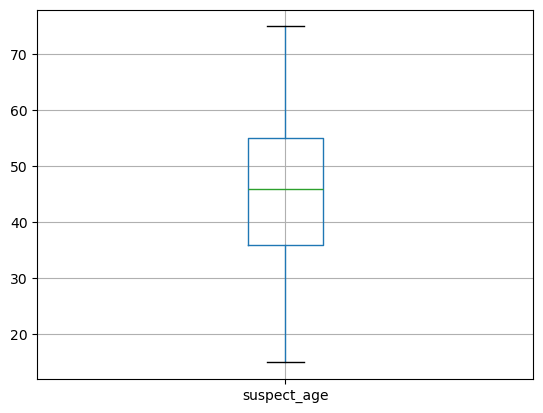

In [118]:
df.boxplot(column='suspect_age')
plt.show()

In [119]:
df["suspect_age"] = df["suspect_age"].where(df["suspect_age"].between(0, 100))
df['suspect_age'].isna().sum()

np.int64(0)

In [120]:
# def outliers(columns):
#   Q1 = columns.quantile(0.25)
#   Q3 = columns.quantile(0.75)
#   IQR = Q3 - Q1
#   Lower_Bound= Q1 - 1.5 * IQR
#   Upper_Bound= Q3 + 1.5 * IQR
#   return columns.clip(
#       lower= Lower_Bound,
#       upper= Upper_Bound
#   )

# num_cols = ['suspect_age']
# df[num_cols] = df[num_cols].apply(outliers)

In [121]:
df['suspect_age'].describe()

count    5050.000000
mean       45.585149
std        14.887150
min        15.000000
25%        36.000000
50%        46.000000
75%        55.000000
max        75.000000
Name: suspect_age, dtype: float64

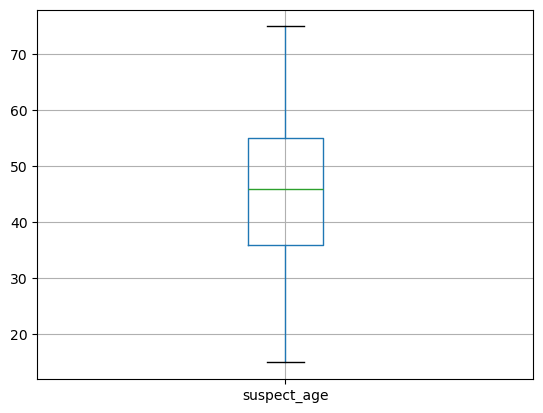

In [122]:
df.boxplot(column='suspect_age')
plt.show()

In [123]:
df['suspect_age'].describe()

count    5050.000000
mean       45.585149
std        14.887150
min        15.000000
25%        36.000000
50%        46.000000
75%        55.000000
max        75.000000
Name: suspect_age, dtype: float64

In [124]:
df['suspect_age'] = df['suspect_age'].fillna(df['suspect_age'].median())
df['suspect_age'].isnull().sum()

np.int64(0)

victim_age

In [125]:
df['victim_age'].describe()

count    5050.000000
mean       49.903366
std        21.050801
min        10.000000
25%        34.000000
50%        50.000000
75%        65.000000
max        90.000000
Name: victim_age, dtype: float64

In [126]:
df['victim_age'].isna().sum()

np.int64(0)

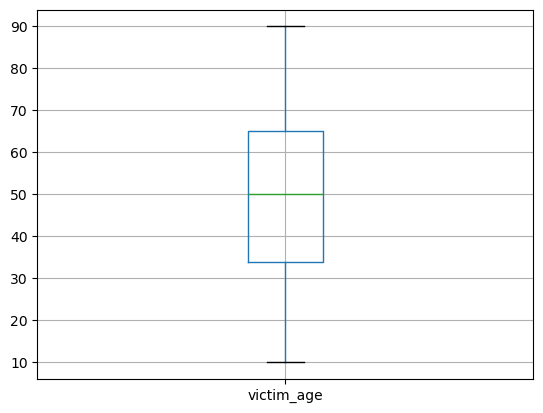

In [127]:
df['victim_age'].isna().sum()
df.boxplot(column='victim_age')
plt.show()

In [128]:
df['victim_age'].describe()

count    5050.000000
mean       49.903366
std        21.050801
min        10.000000
25%        34.000000
50%        50.000000
75%        65.000000
max        90.000000
Name: victim_age, dtype: float64

In [129]:
# def outliers(columns):
#   Q1 = columns.quantile(0.25)
#   Q3 = columns.quantile(0.75)
#   IQR = Q3 - Q1
#   Lower_Bound= Q1 - 1.5 * IQR
#   Upper_Bound= Q3 + 1.5 * IQR
#   return columns.clip(
#       lower= Lower_Bound,
#       upper= Upper_Bound
#   )

# num_cols = ['victim_age']
# df[num_cols] = df[num_cols].apply(outliers)

In [130]:
df["victim_age"] = df["victim_age"].where( df["victim_age"].between(0, 100))
df['victim_age'].isna().sum()

np.int64(0)

In [131]:
df['victim_age'].describe()

count    5050.000000
mean       49.903366
std        21.050801
min        10.000000
25%        34.000000
50%        50.000000
75%        65.000000
max        90.000000
Name: victim_age, dtype: float64

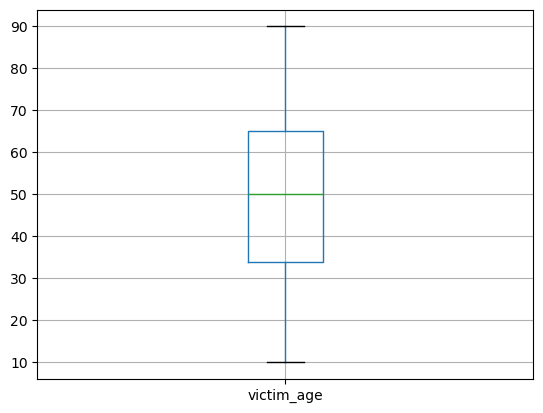

In [132]:
df.boxplot(column='victim_age')
plt.show()

In [133]:
df['victim_age'] = df['victim_age'].fillna(df['victim_age'].median())
df['victim_age'].isnull().sum()

np.int64(0)

#### Handaling **num_arrests** Column *Ask instructor*

In [134]:
df['num_arrests'].isnull().sum()

np.int64(0)

In [135]:
sorted(df["num_arrests"].unique())

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

In [136]:
df["num_arrests"] = (
    pd.to_numeric(df["num_arrests"], errors="coerce").abs().astype("Int64")
)

In [137]:
df['num_arrests'].unique()

<IntegerArray>
[0, 2, 5, 1, 3, 4]
Length: 6, dtype: Int64

In [138]:
df["num_arrests"].isna().sum()

np.int64(0)

In [139]:
df['num_arrests'] = df['num_arrests'].fillna(df['num_arrests'].mode()[0])
df['num_arrests'].isnull().sum()

np.int64(0)

property_loss_usd

In [140]:
df["property_loss_usd"].isna().sum()

np.int64(0)

In [141]:
#  From Object to Int type
df["property_loss_usd"] = pd.to_numeric(df["property_loss_usd"],errors="coerce")

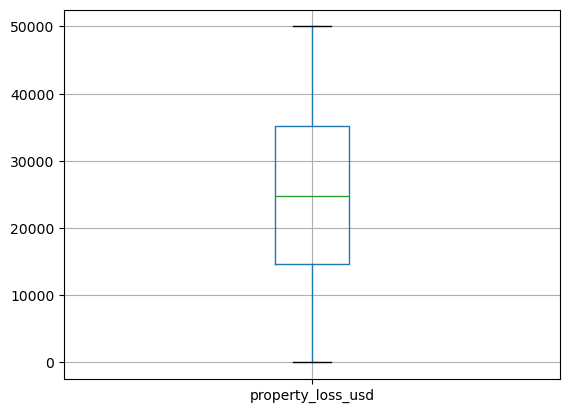

In [142]:
df.boxplot(column='property_loss_usd')
plt.show()

In [143]:
df["property_loss_usd"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5050 entries, 0 to 5049
Series name: property_loss_usd
Non-Null Count  Dtype  
--------------  -----  
5050 non-null   float64
dtypes: float64(1)
memory usage: 39.6 KB


In [144]:
df['property_loss_usd'].describe()

count     5050.000000
mean     24893.950038
std      13316.015797
min         20.660000
25%      14605.625000
50%      24725.400000
75%      35190.145000
max      49998.300000
Name: property_loss_usd, dtype: float64

In [145]:
df["property_loss_usd"] = pd.to_numeric(df["property_loss_usd"], errors="coerce").abs()

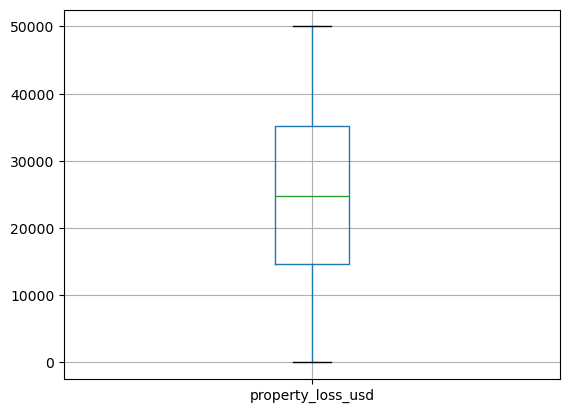

In [146]:
df.boxplot(column='property_loss_usd')
plt.show()

In [147]:
df["property_loss_usd"].isna().sum()

np.int64(0)

In [148]:
df['property_loss_usd'] = df['property_loss_usd'].fillna(df['property_loss_usd'].median())
df['property_loss_usd'].isnull().sum()

np.int64(0)

<Axes: >

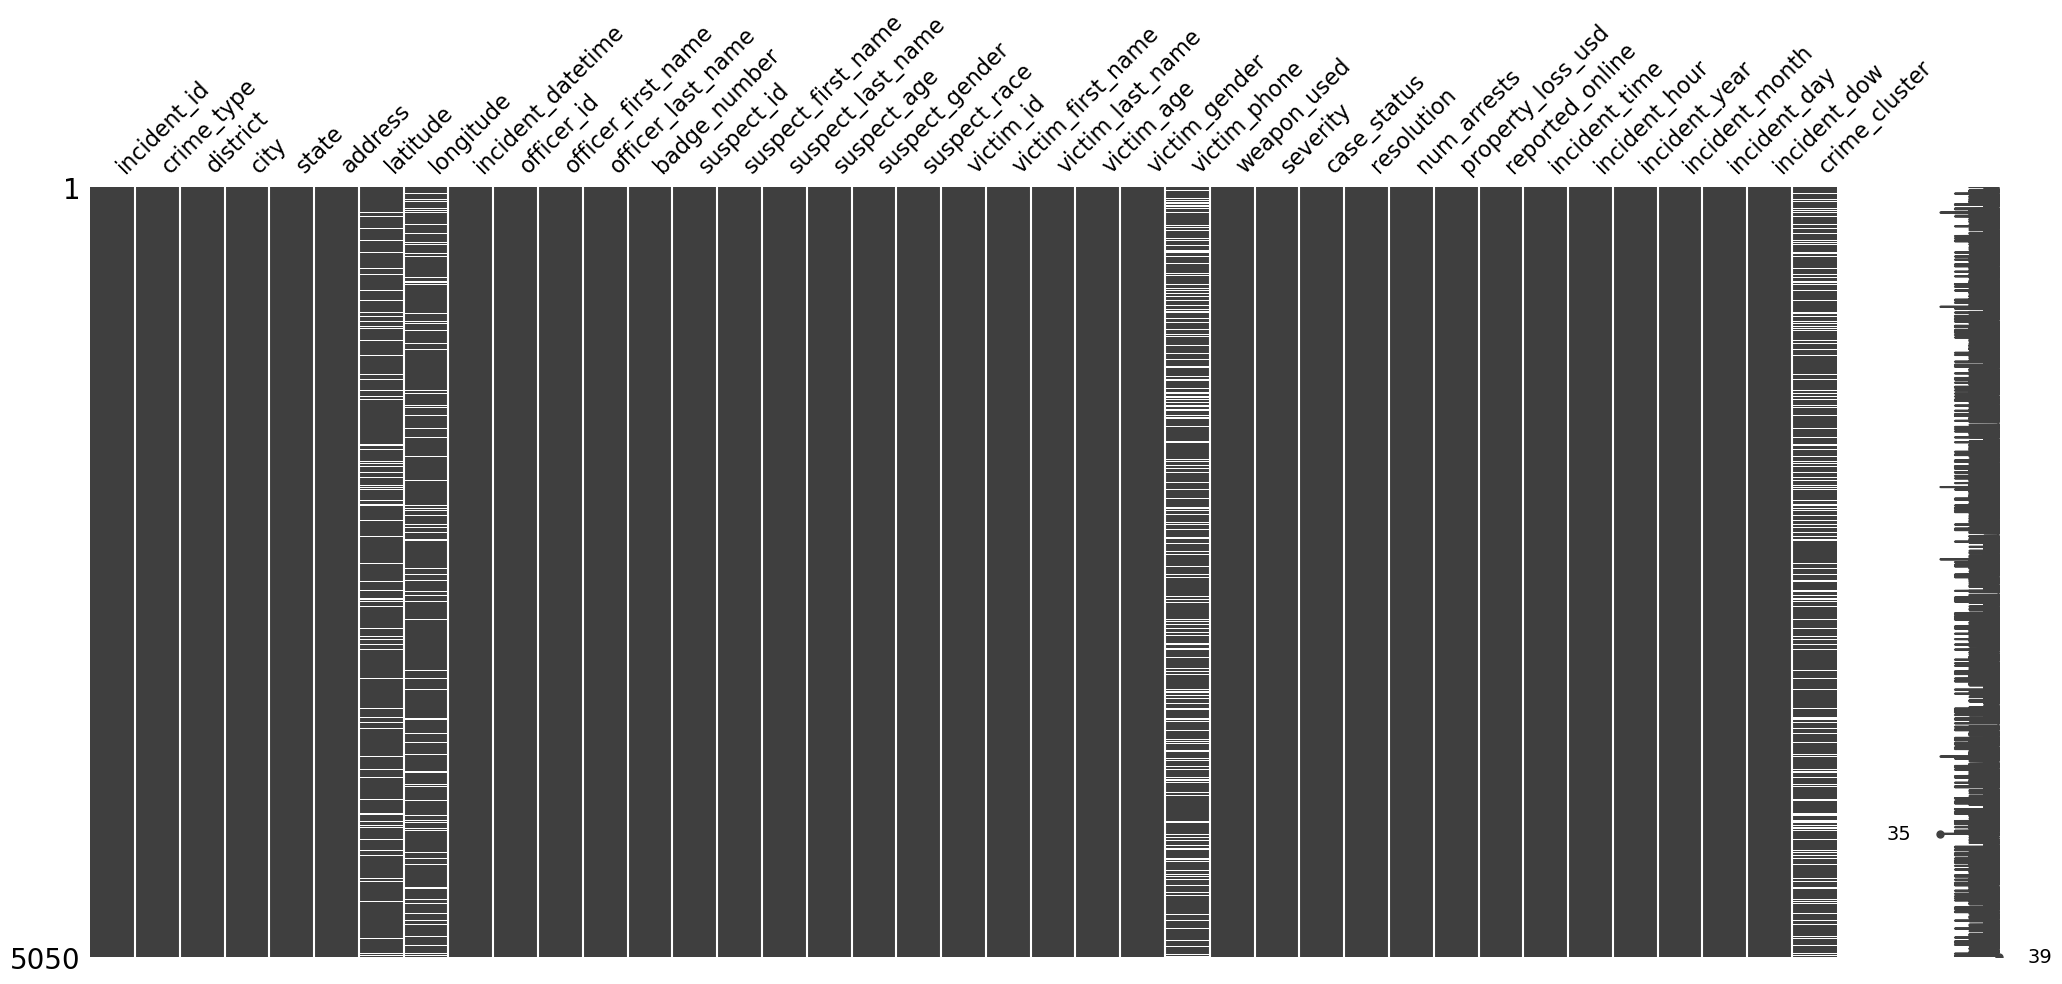

In [149]:
msno.matrix(df)

### Pattern Discovery Using K-Means Clustering


In [150]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df['incident_datetime'] = pd.to_datetime(df['incident_datetime'], errors='coerce')
df['incident_hour'] = df['incident_datetime'].dt.hour.fillna(df['incident_datetime'].dt.hour.median())

features = ['latitude', 'longitude', 'incident_hour', 'property_loss_usd']
cluster_df = df[features].dropna()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[cluster_df.index, 'crime_cluster'] = kmeans.fit_predict(scaled_features)

df.groupby('crime_cluster')[['property_loss_usd', 'incident_hour', 'latitude', 'longitude']].mean()

,property_loss_usd,incident_hour,latitude,longitude
crime_cluster,,,,
0.0,25251.602041,13.075435,41.827801,-110.190448
1.0,23784.288248,8.694129,42.058840,-82.091776
2.0,26385.865828,17.647705,31.038262,-91.869581
3.0,23854.497794,4.490054,31.273715,-98.336113


### Interactive Crime Metrics Explorer

In [151]:
import ipywidgets as widgets

def show_crime_stats(crime_type):
    sub = df[df['crime_type'] == crime_type]
    print(f"Total Incidents: {len(sub)}")
    print(f"Mean Property Loss: ${sub['property_loss_usd'].mean():,.2f}")
    if not sub['district'].empty:
        print(f"Top District: {sub['district'].mode()[0]}")
    if not sub['weapon_used'].empty:
        print(f"Top Weapon: {sub['weapon_used'].mode()[0]}")

crime_dropdown = widgets.Dropdown(
    options=sorted(df['crime_type'].dropna().unique()),
    description='Crime Type:',
    disabled=False
)

widgets.interact(show_crime_stats, crime_type=crime_dropdown);

interactive(children=(Dropdown(description='Crime Type:', options=('Abduction', 'Armed Robbery', 'Arson', 'Ass…

## Data Visualization (Matplotlib)


In [152]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
df.shape

(5050, 39)

### 1. Crime Type Distribution

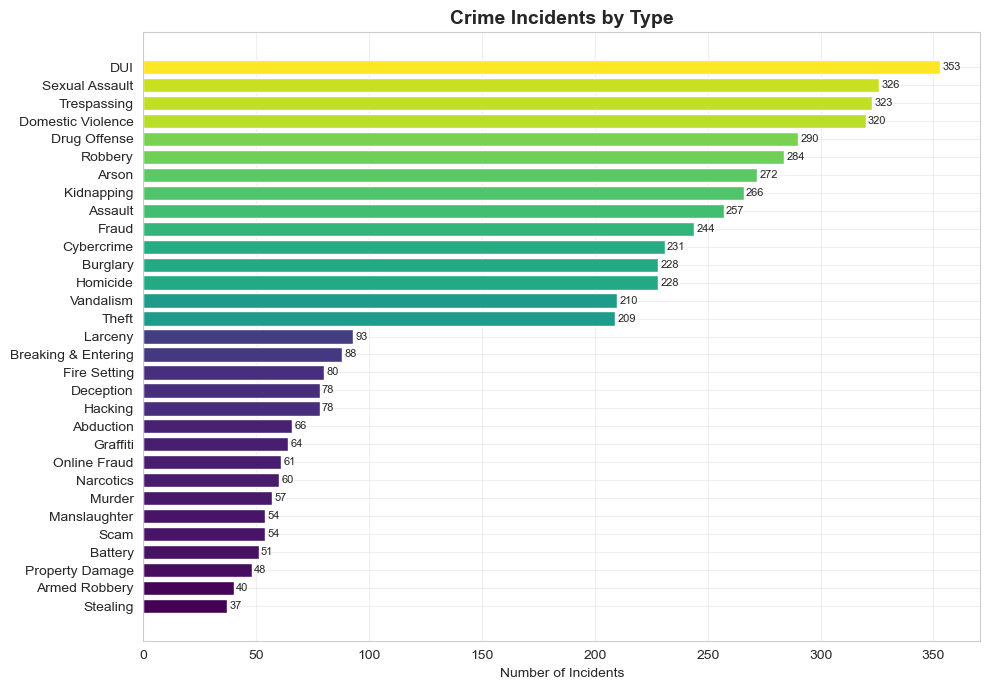

In [153]:
crime_counts = df['crime_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(crime_counts.index[::-1], crime_counts.values[::-1], color=plt.cm.viridis(
    (crime_counts.values[::-1] - crime_counts.values.min()) / (crime_counts.values.max() - crime_counts.values.min())
))
ax.set_xlabel('Number of Incidents')
ax.set_title('Crime Incidents by Type', fontsize=14, fontweight='bold')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 2. Incidents Over Time (Yearly & Monthly Trend)

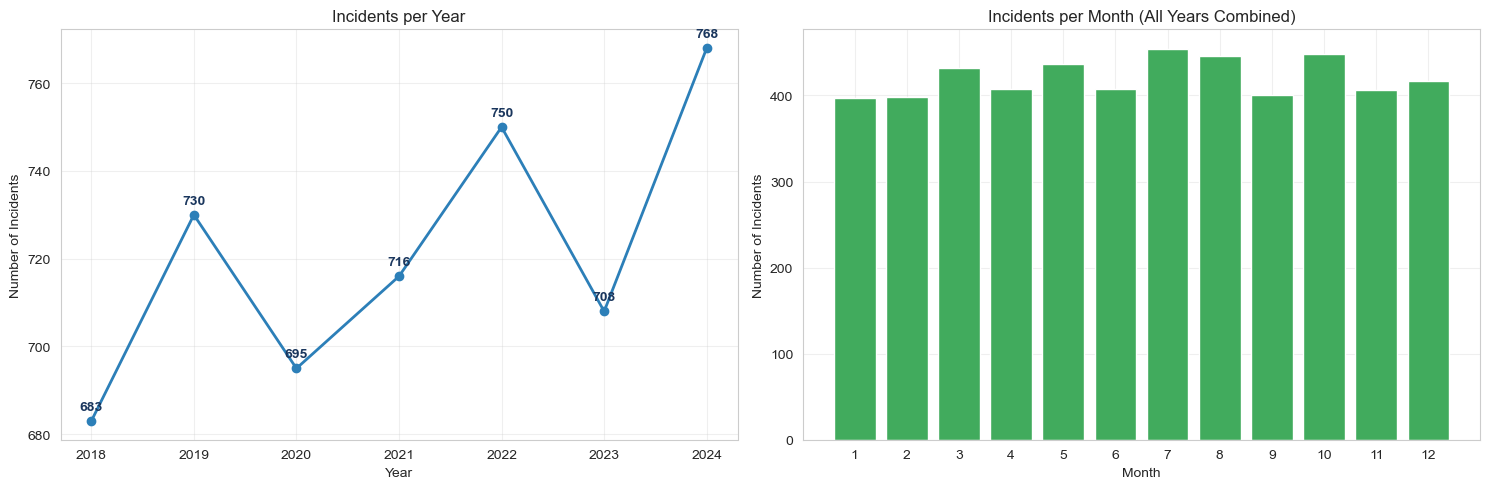

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly = df['incident_year'].value_counts().sort_index()
axes[0].plot(yearly.index, yearly.values, marker='o', color='#2c7fb8', linewidth=2)
axes[0].set_title('Incidents per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Incidents')

for x, y in zip(yearly.index, yearly.values):
    axes[0].annotate(f'{int(y)}', 
                     (x, y), 
                     textcoords="offset points", 
                     xytext=(0, 8), 
                     ha='center', 
                     fontweight='bold', 
                     fontsize=10, 
                     color='#1a365d')

monthly = df['incident_month'].value_counts().sort_index()
axes[1].bar(monthly.index, monthly.values, color='#41ab5d')
axes[1].set_title('Incidents per Month (All Years Combined)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Incidents')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

### 3. Incidents by Hour of Day

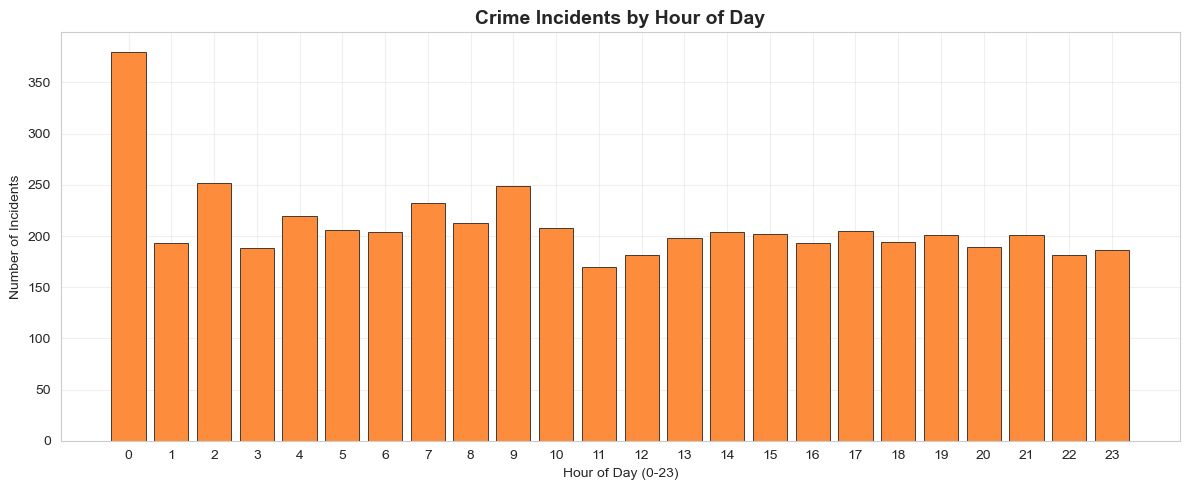

In [155]:
hourly = df['incident_hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly.index, hourly.values, color='#fd8d3c', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Number of Incidents')
ax.set_title('Crime Incidents by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 4. Severity Breakdown

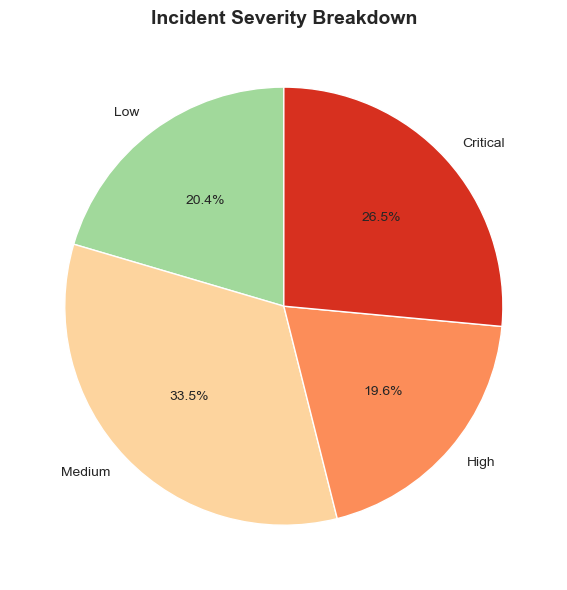

In [156]:
severity_order = ['Low', 'Medium', 'High', 'Critical']
severity_counts = df['severity'].value_counts().reindex(
    [s for s in severity_order if s in df['severity'].unique()]
).dropna()

colors = {'Low': '#a1d99b', 'Medium': '#fdd49e', 'High': '#fc8d59', 'Critical': '#d7301f'}
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
       colors=[colors.get(s, '#999999') for s in severity_counts.index], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax.set_title('Incident Severity Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Incidents by District

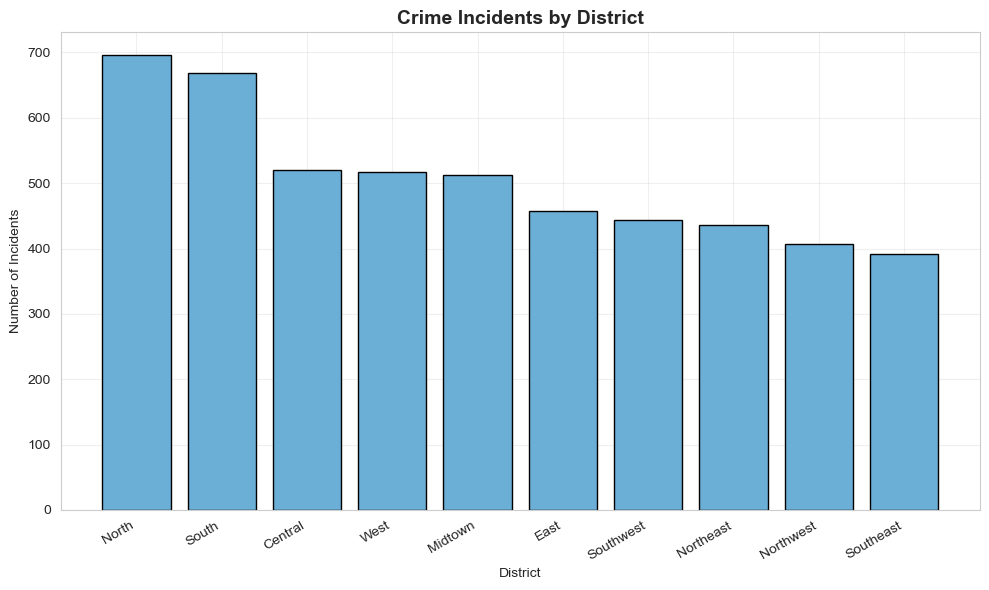

In [157]:
district_counts = df['district'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(district_counts.index, district_counts.values, color='#6baed6', edgecolor='black')
ax.set_xlabel('District')
ax.set_ylabel('Number of Incidents')
ax.set_title('Crime Incidents by District', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 6. Case Status & Resolution

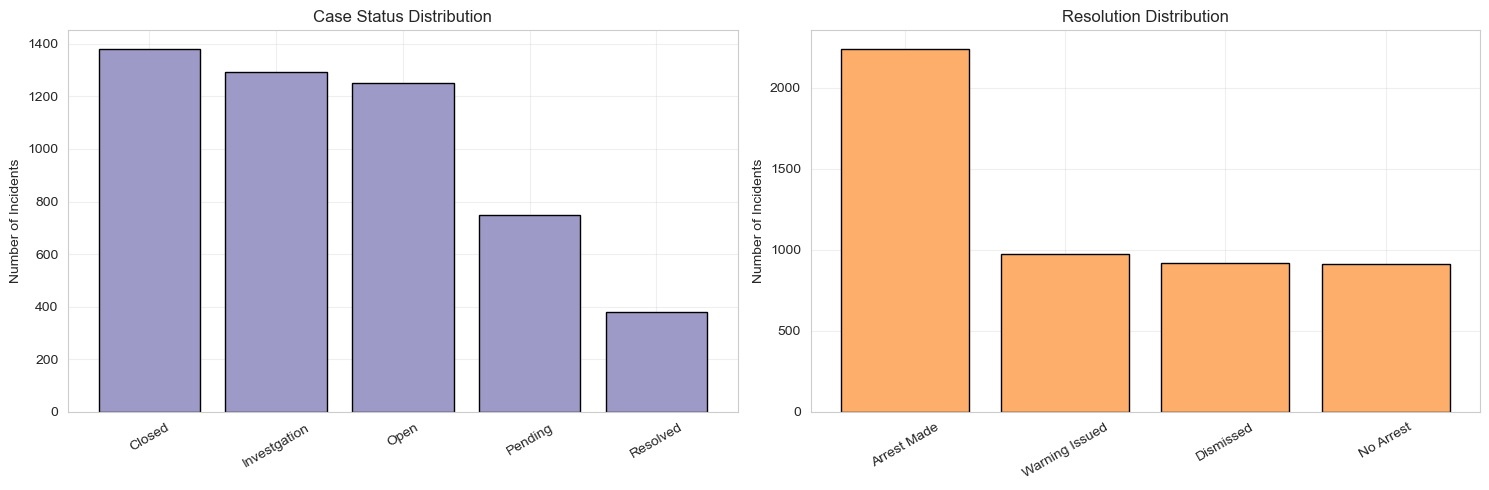

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

case_status_counts = df['case_status'].value_counts()
axes[0].bar(case_status_counts.index, case_status_counts.values, color='#9e9ac8', edgecolor='black')
axes[0].set_title('Case Status Distribution')
axes[0].set_ylabel('Number of Incidents')
axes[0].tick_params(axis='x', rotation=30)

resolution_counts = df['resolution'].value_counts()
axes[1].bar(resolution_counts.index, resolution_counts.values, color='#fdae6b', edgecolor='black')
axes[1].set_title('Resolution Distribution')
axes[1].set_ylabel('Number of Incidents')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 7. Suspect Age & Victim Age Distributions

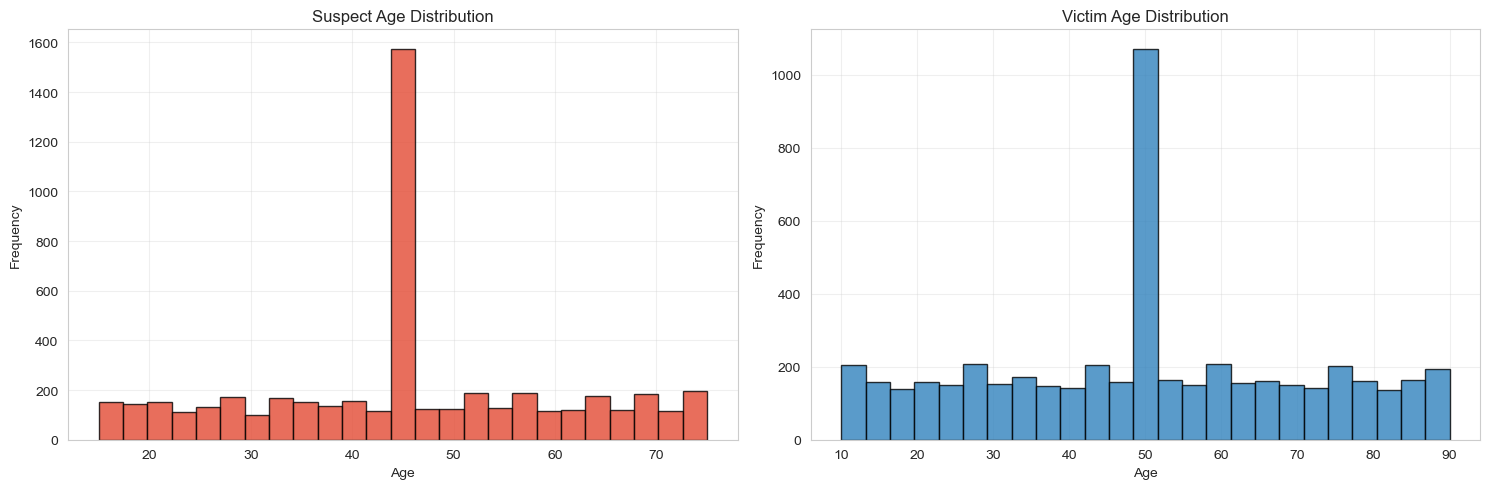

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['suspect_age'].dropna(), bins=25, color='#e34a33', edgecolor='black', alpha=0.8)
axes[0].set_title('Suspect Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['victim_age'].dropna(), bins=25, color='#3182bd', edgecolor='black', alpha=0.8)
axes[1].set_title('Victim Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 8. Property Loss by Crime Type

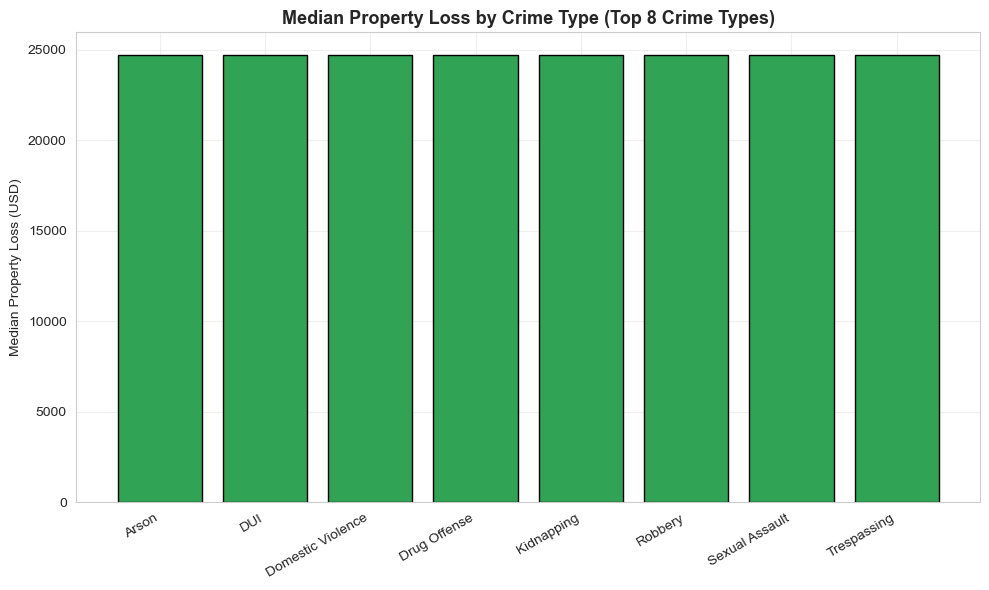

In [160]:
top_crimes = df['crime_type'].value_counts().head(8).index
loss_by_crime = df[df['crime_type'].isin(top_crimes)].groupby('crime_type')['property_loss_usd'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(loss_by_crime.index, loss_by_crime.values, color='#31a354', edgecolor='black')
ax.set_ylabel('Median Property Loss (USD)')
ax.set_title('Median Property Loss by Crime Type (Top 8 Crime Types)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 9. Weapon Used Breakdown

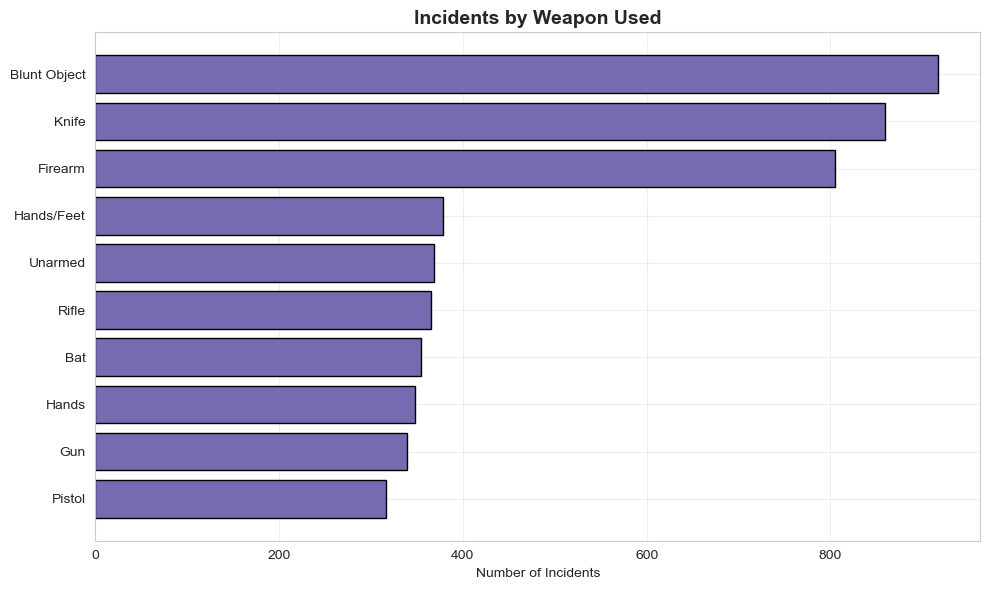

In [161]:
weapon_counts = df['weapon_used'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(weapon_counts.index[::-1], weapon_counts.values[::-1], color='#756bb1', edgecolor='black')
ax.set_xlabel('Number of Incidents')
ax.set_title('Incidents by Weapon Used', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10. Heatmap: Incidents by Day of Week vs Hour

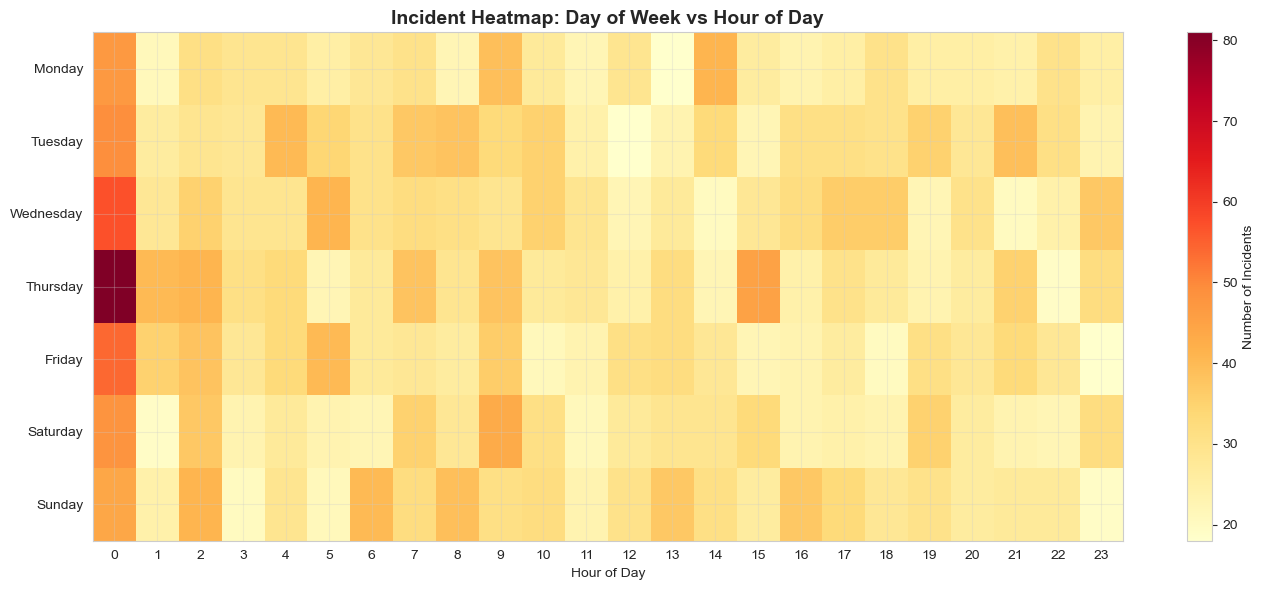

In [162]:
df['incident_dow'] = df['incident_datetime'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heat_data = df.groupby(['incident_dow', 'incident_hour']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat_data.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(dow_order)))
ax.set_yticklabels(dow_order)
ax.set_xticks(range(0, 24))
ax.set_xticklabels(range(0, 24))
ax.set_xlabel('Hour of Day')
ax.set_title('Incident Heatmap: Day of Week vs Hour of Day', fontsize=14, fontweight='bold')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Number of Incidents')
plt.tight_layout()
plt.show()

### 11. Geographic Scatter of Incidents (Lat/Lon)

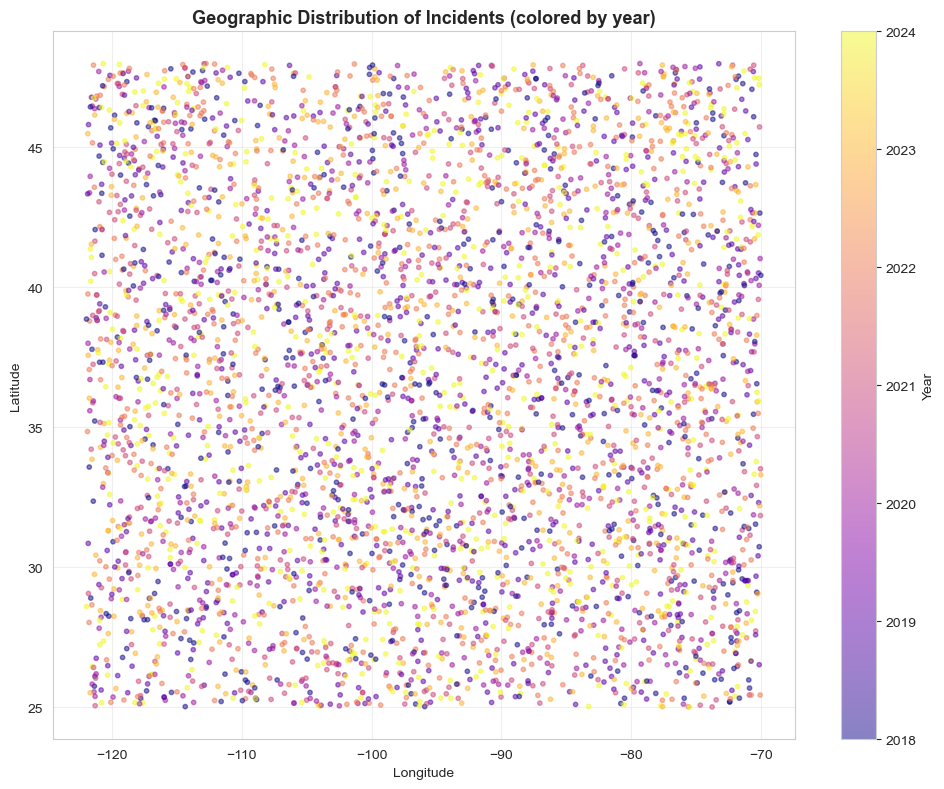

In [163]:
geo = df.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(geo['longitude'], geo['latitude'], c=geo['incident_year'],
                      cmap='plasma', alpha=0.5, s=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Incidents (colored by year)', fontsize=13, fontweight='bold')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Year')
plt.tight_layout()
plt.show()

### 12. Suspect vs Victim Gender Comparison

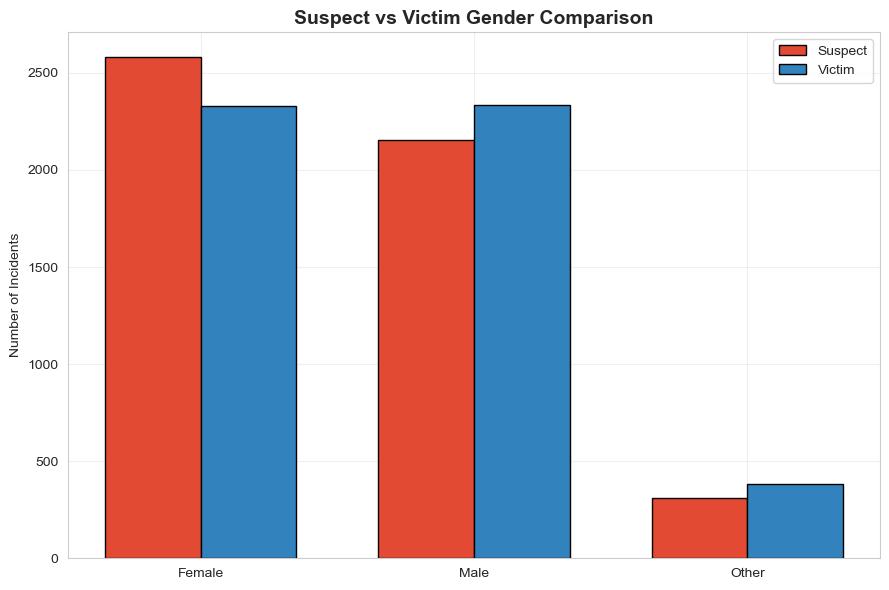

In [164]:
suspect_gender_counts = df['suspect_gender'].value_counts()
victim_gender_counts = df['victim_gender'].value_counts()

genders = sorted(set(suspect_gender_counts.index) | set(victim_gender_counts.index))
suspect_vals = [suspect_gender_counts.get(g, 0) for g in genders]
victim_vals = [victim_gender_counts.get(g, 0) for g in genders]

x = np.arange(len(genders))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, suspect_vals, width, label='Suspect', color='#e34a33', edgecolor='black')
ax.bar(x + width/2, victim_vals, width, label='Victim', color='#3182bd', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(genders)
ax.set_ylabel('Number of Incidents')
ax.set_title('Suspect vs Victim Gender Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [165]:
df.to_csv("crime_incidents_cleaned2.csv", index=False)

### 12. Suspect vs Victim Gender Comparison

In [166]:
pip install streamlit pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [167]:
df.to_csv("crime_incidents_cleaned.csv", index=False)

### 🖥️ Streamlit Interactive Dashboard Code

from __future__ import annotations

import os
import re
from typing import Optional

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import streamlit as st

DATA_FILENAME = "crime_incidents_messy.csv"
DATA_FILENAME_FALLBACK = r"D:\Data\archive\crime_incidents_messy.csv"

BG = "#0B1220"
PANEL = "#131B2E"
BORDER = "#22304A"
TEXT = "#E7ECF5"
TEXT_MUTED = "#8592AC"

ACCENT_AMBER = "#F2A93B"
ACCENT_CYAN = "#33C2FF"
ACCENT_VIOLET = "#A78BFA"
ACCENT_GREEN = "#34D399"
ACCENT_RED = "#F0454B"
ACCENT_ORANGE = "#FB923C"
ACCENT_BLUE = "#60A5FA"
ACCENT_PINK = "#F472B6"

SEVERITY_ORDER = ["Low", "Medium", "High", "Critical", "Unknown"]
SEVERITY_COLORS = {
    "Low": ACCENT_GREEN,
    "Medium": "#FBBF24",
    "High": ACCENT_ORANGE,
    "Critical": ACCENT_RED,
    "Unknown": TEXT_MUTED,
}

QUALITATIVE_PALETTE = [
    ACCENT_CYAN,
    ACCENT_AMBER,
    ACCENT_VIOLET,
    ACCENT_GREEN,
    ACCENT_RED,
    ACCENT_ORANGE,
    ACCENT_BLUE,
    ACCENT_PINK,
    "#4ADE80",
    "#38BDF8",
    "#FCA5A5",
    "#C084FC",
]

FONT_FAMILY = "Inter, -apple-system, sans-serif"
HEADER_FONT_FAMILY = "'Space Grotesk', Inter, sans-serif"

CHART_H = 205
CHART_H_LARGE = 245

DOW_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

CRIME_TYPE_MAPPING = {
    "Arsen": "Arson",
    "Asslt": "Assault",
    "B&E": "Breaking & Entering",
    "Burglry": "Burglary",
    "Cyber Crime": "Cybercrime",
    "D.U.I.": "DUI",
    "Dui": "DUI",
    "Duii": "DUI",
    "Dwi": "DUI",
    "Drunk Driving": "DUI",
    "Dom. Violence": "Domestic Violence",
    "Domestc Violence": "Domestic Violence",
    "Drug Offence": "Drug Offense",
    "Drugs": "Drug Offense",
    "Narcotics": "Drug Offense",
    "Dv": "Domestic Violence",
    "Homocide": "Homicide",
    "Kidnaping": "Kidnapping",
    "Robbry": "Robbery",
    "Roberry": "Robbery",
    "Sa": "Sexual Assault",
    "Sex Assault": "Sexual Assault",
    "Sexual Assualt": "Sexual Assault",
    "Tresspassing": "Trespassing",
    "Trespass": "Trespassing",
    "Vandlism": "Vandalism",
    "Fire Setting": "Arson",
    "Deception": "Fraud",
    "Fraudulent Activity": "Fraud",
    "Online Fraud": "Fraud",
    "Scam": "Fraud",
    "Murder": "Homicide",
    "Manslaughter": "Homicide",
    "Larceny": "Theft/Larceny",
    "Theft": "Theft/Larceny",
    "Stealing": "Theft/Larceny",
}
DISTRICT_MAPPING = {
    "Cen": "Central",
    "Eas": "East",
    "Mid": "Midtown",
    "Nor": "North",
    "Sou": "South",
    "Wes": "West",
}
GENDER_MAPPING = {"F": "Female", "M": "Male", "Unknow": "Unknown"}
VICTIM_GENDER_MAPPING = {
    "M": "Male",
    "F": "Female",
    "Other": "Other",
    "Unknown": "Unknown",
}
CASE_STATUS_MAPPING = {"Pendng": "Pending", "Investgation": "Under Investigation"}
WEAPON_MAPPING = {
    "Gun": "Firearm",
    "Pistol": "Firearm",
    "Rifle": "Firearm",
    "Hands": "Hands / Unarmed",
    "Hands/Feet": "Hands / Unarmed",
    "Unarmed": "Hands / Unarmed",
    "Bat": "Blunt Object",
}
RESOLUTION_MAPPING = {
    "Arres Made": "Arrest Made",
    "Warning Issued": "Warning",
    "Case Dismissed": "Dismissed",
}
SEVERITY_MAPPING = {
    "1": "Low",
    "2": "Medium",
    "3": "High",
    "4": "Critical",
    "med": "Medium",
    "Med": "Medium",
    "medium": "Medium",
    "low": "Low",
    "high": "High",
    "Medium": "Medium",
    "crit": "Critical",
    "Crit": "Critical",
    "criticl": "Critical",
    "critical": "Critical",
}
REPORTED_ONLINE_MAPPING = {
    "True": True,
    "Yes": True,
    "1": True,
    "False": False,
    "No": False,
    "0": False,
}

PII_COLUMNS_TO_DROP = [
    "officer_first_name",
    "officer_last_name",
    "suspect_first_name",
    "suspect_last_name",
    "victim_first_name",
    "victim_last_name",
    "victim_phone",
    "address",
    "notes",
]


def inject_custom_css() -> None:
  st.markdown(
      f"""
        <style>
        @import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@500;600;700&family=Inter:wght@400;500;600;700&display=swap');

        html, body, [class*="css"] {{
            font-family: {FONT_FAMILY};
        }}

        .stApp {{
            background: {BG};
        }}

        .block-container {{
            padding-top: 0.5rem;
            padding-bottom: 0.3rem;
            padding-left: 1.4rem;
            padding-right: 1.4rem;
            max-width: 100%;
        }}
        #MainMenu {{ visibility: hidden; }}
        footer {{ visibility: hidden; }}
        div[data-testid="stHeader"] {{ background: transparent; height: 0.4rem; }}
        div[data-testid="stDecoration"] {{ display: none; }}
        div[data-testid="stVerticalBlock"] {{ gap: 0.5rem; }}
        div[data-testid="stElementContainer"] {{ margin-bottom: 0; }}

        section[data-testid="stSidebar"] {{
            background: {PANEL};
            border-right: 1px solid {BORDER};
        }}
        section[data-testid="stSidebar"] .block-container {{
            padding-top: 1.2rem;
        }}

        h1, h2, h3, .dash-title {{
            font-family: {HEADER_FONT_FAMILY};
            color: {TEXT};
        }}
        p, span, label, div {{
            color: {TEXT};
        }}

        .dash-header {{
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0.2rem 0 0.4rem 0;
            border-bottom: 1px solid {BORDER};
            margin-bottom: 0.5rem;
        }}
        .dash-title {{
            font-size: 1.35rem;
            font-weight: 700;
            margin: 0;
            letter-spacing: 0.2px;
        }}
        .dash-subtitle {{
            font-size: 0.78rem;
            color: {TEXT_MUTED};
            margin-top: 0.1rem;
        }}

        .kpi-card {{
            background: {PANEL};
            border: 1px solid {BORDER};
            border-top: 3px solid var(--kpi-accent, {ACCENT_CYAN});
            border-radius: 10px;
            padding: 0.55rem 0.8rem;
            min-height: 84px;
            display: flex;
            flex-direction: column;
            justify-content: center;
            gap: 0.1rem;
        }}
        .kpi-icon {{ font-size: 1.05rem; opacity: 0.9; line-height: 1; }}
        .kpi-value {{
            font-family: {HEADER_FONT_FAMILY};
            font-size: 1.35rem;
            font-weight: 700;
            line-height: 1.15;
            color: {TEXT};
            white-space: nowrap;
        }}
        .kpi-label {{
            font-size: 0.68rem;
            color: {TEXT_MUTED};
            text-transform: none;
            letter-spacing: 0.2px;
            line-height: 1.2;
        }}

        div[class*="st-key-chart_card_"] {{
            background: {PANEL} !important;
            border: 1px solid {BORDER} !important;
            border-radius: 10px !important;
            padding: 0.5rem 0.7rem 0.35rem 0.7rem !important;
        }}
        .chart-card-title {{
            font-size: 0.82rem;
            font-weight: 600;
            color: {TEXT};
            margin-bottom: 0.2rem;
        }}

        button[data-baseweb="tab"] {{
            font-family: {HEADER_FONT_FAMILY};
            font-size: 0.9rem;
            color: {TEXT_MUTED};
        }}
        button[data-baseweb="tab"][aria-selected="true"] {{
            color: {ACCENT_AMBER};
        }}
        div[data-baseweb="tab-highlight"] {{
            background-color: {ACCENT_AMBER};
        }}
        div[data-baseweb="tab-border"] {{
            background-color: {BORDER};
        }}

        div.stButton > button {{
            background: {PANEL};
            border: 1px solid {ACCENT_AMBER};
            color: {ACCENT_AMBER};
            border-radius: 8px;
            font-size: 0.8rem;
            padding: 0.3rem 0.8rem;
        }}
        div.stButton > button:hover {{
            background: {ACCENT_AMBER};
            color: {BG};
            border: 1px solid {ACCENT_AMBER};
        }}

        span[data-baseweb="tag"] {{
            background-color: {ACCENT_AMBER} !important;
            color: {BG} !important;
        }}
        </style>
        """,
      unsafe_allow_html=True,
  )


def load_raw_data(uploaded_file) -> Optional[pd.DataFrame]:
  try:
    if os.path.exists(DATA_FILENAME):
      return pd.read_csv(DATA_FILENAME)
    if os.path.exists(DATA_FILENAME_FALLBACK):
      return pd.read_csv(DATA_FILENAME_FALLBACK)
    if uploaded_file is not None:
      return pd.read_csv(uploaded_file)
  except Exception as exc:
    st.error(f"Could not read the CSV file: {exc}")
  return None


def _normalize_key(value) -> str:
  return " ".join(str(value).strip().lower().split())


def apply_alias_mapping(series: pd.Series, mapping: dict) -> pd.Series:
  normalized_map = {_normalize_key(k): v for k, v in mapping.items()}

  def _resolve(value):
    if pd.isna(value):
      return value
    return normalized_map.get(_normalize_key(value), value)

  return series.apply(_resolve)


def _clip_outliers_iqr(series: pd.Series) -> pd.Series:
  q1, q3 = series.quantile(0.25), series.quantile(0.75)
  iqr = q3 - q1
  lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  return series.clip(lower=lower, upper=upper)


@st.cache_data(show_spinner="Cleaning and preparing the dataset…")
def clean_crime_data(df_raw: pd.DataFrame) -> pd.DataFrame:
  df = df_raw.copy()

  df.drop_duplicates(subset="incident_id", inplace=True)

  cat_cols = df.select_dtypes(include="object").columns
  df[cat_cols] = df[cat_cols].apply(
      lambda x: (
          x.str.strip().str.replace(r"\s+", " ", regex=True).str.lower().str.title()
      )
  )

  df["crime_type"] = apply_alias_mapping(df["crime_type"], CRIME_TYPE_MAPPING)
  df["district"] = apply_alias_mapping(df["district"], DISTRICT_MAPPING)

  df["suspect_gender"] = apply_alias_mapping(
      df["suspect_gender"], GENDER_MAPPING
  ).fillna("Unknown")
  df["victim_gender"] = apply_alias_mapping(
      df["victim_gender"], VICTIM_GENDER_MAPPING
  )

  df["weapon_used"] = apply_alias_mapping(df["weapon_used"], WEAPON_MAPPING)
  df["resolution"] = apply_alias_mapping(df["resolution"], RESOLUTION_MAPPING)
  df["case_status"] = apply_alias_mapping(
      df["case_status"], CASE_STATUS_MAPPING
  )
  df["severity"] = apply_alias_mapping(
      df["severity"], SEVERITY_MAPPING
  ).fillna("Unknown")

  fill_unknown_cols = [
      "victim_id",
      "victim_gender",
      "weapon_used",
      "case_status",
      "resolution",
  ]
  for col in fill_unknown_cols:
    if col in df.columns:
      df[col] = df[col].fillna("Unknown")

  df["reported_online"] = df["reported_online"].replace(REPORTED_ONLINE_MAPPING)
  df["reported_online"] = df["reported_online"].apply(
      lambda v: v if isinstance(v, bool) else ("Unknown" if pd.isna(v) else v)
  )

  df["latitude"] = df["latitude"].where(df["latitude"].between(24, 49))
  df["longitude"] = df["longitude"].where(df["longitude"].between(-125, -67))

  raw_dt_str = df["incident_datetime"].astype(str)
  has_time_component = raw_dt_str.str.contains(":", na=False)

  df["incident_datetime"] = pd.to_datetime(
      df["incident_datetime"], format="mixed", errors="coerce"
  )
  df["incident_hour"] = df["incident_datetime"].dt.hour.where(
      has_time_component
  )
  df["incident_year"] = df["incident_datetime"].dt.year
  df["incident_month"] = df["incident_datetime"].dt.month
  df["incident_day"] = df["incident_datetime"].dt.day
  df["incident_dow"] = df["incident_datetime"].dt.day_name()

  for age_col in ["suspect_age", "victim_age"]:
    df[age_col] = df[age_col].where(df[age_col].between(0, 100))
    df[age_col] = _clip_outliers_iqr(df[age_col])

  df["num_arrests"] = (
      pd.to_numeric(df["num_arrests"], errors="coerce").abs().astype("Int64")
  )
  df["property_loss_usd"] = pd.to_numeric(
      df["property_loss_usd"], errors="coerce"
  ).abs()
  df["property_loss_usd"] = _clip_outliers_iqr(df["property_loss_usd"])

  df["hour_for_cluster"] = df["incident_hour"].fillna(
      df["incident_hour"].median()
  )
  features = ["latitude", "longitude", "hour_for_cluster", "property_loss_usd"]
  valid_cluster_idx = df[features].dropna().index

  if len(valid_cluster_idx) > 10:
    scaler = StandardScaler()
    scaled_feats = scaler.fit_transform(df.loc[valid_cluster_idx, features])
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df.loc[valid_cluster_idx, "crime_cluster"] = kmeans.fit_predict(
        scaled_feats
    ).astype(str)
  else:
    df["crime_cluster"] = "Unassigned"

  df.drop(
      columns=[c for c in PII_COLUMNS_TO_DROP if c in df.columns],
      inplace=True,
      errors="ignore",
  )
  return df


FILTER_KEYS = [
    "f_year_range",
    "f_crime_type",
    "f_district",
    "f_severity",
    "f_case_status",
    "f_weapon",
]


def _reset_filters() -> None:
  for key in FILTER_KEYS:
    st.session_state.pop(key, None)


def render_sidebar_filters(df: pd.DataFrame) -> dict:
  with st.sidebar:
    st.markdown(
        f"<div style='display:flex;align-items:center;gap:0.5rem;margin-bottom:0.2rem;'>"
        f"<span style='font-size:1.3rem;'>🛡️</span>"
        f"<span style='font-family:{HEADER_FONT_FAMILY};font-size:1.05rem;font-weight:700;'>"
        f"CRIME ANALYTICS</span></div>",
        unsafe_allow_html=True,
    )
    st.caption("Filters apply to every tab")
    st.button("🔄 Reset Filters", on_click=_reset_filters, width="stretch")
    st.markdown("---")

    years = df["incident_year"].dropna()
    year_min, year_max = (
        (int(years.min()), int(years.max())) if not years.empty else (2018, 2024)
    )

    st.markdown("**📅 Year Range**")
    year_range = st.slider(
        "Year range",
        year_min,
        year_max,
        (year_min, year_max),
        key="f_year_range",
        label_visibility="collapsed",
    )

    st.markdown("**🗂️ Crime Type**")
    crime_types = sorted(df["crime_type"].dropna().unique())
    sel_crime = st.multiselect(
        "Crime type",
        crime_types,
        default=crime_types,
        key="f_crime_type",
        label_visibility="collapsed",
    )

    st.markdown("**📍 District**")
    districts = sorted(df["district"].dropna().unique())
    sel_district = st.multiselect(
        "District",
        districts,
        default=districts,
        key="f_district",
        label_visibility="collapsed",
    )

    st.markdown("**⚠️ Severity**")
    severities = [s for s in SEVERITY_ORDER if s in df["severity"].unique()]
    sel_severity = st.multiselect(
        "Severity",
        severities,
        default=severities,
        key="f_severity",
        label_visibility="collapsed",
    )

    st.markdown("**📁 Case Status**")
    statuses = sorted(df["case_status"].dropna().unique())
    sel_status = st.multiselect(
        "Case status",
        statuses,
        default=statuses,
        key="f_case_status",
        label_visibility="collapsed",
    )

    st.markdown("**🔫 Weapon Used**")
    weapons = sorted(df["weapon_used"].dropna().unique())
    sel_weapon = st.multiselect(
        "Weapon used",
        weapons,
        default=weapons,
        key="f_weapon",
        label_visibility="collapsed",
    )

    st.markdown("---")
    st.caption(
        "Built with Streamlit + Plotly · data cleaned per the notebook pipeline"
    )

  return {
      "year_range": year_range,
      "crime_type": sel_crime,
      "district": sel_district,
      "severity": sel_severity,
      "case_status": sel_status,
      "weapon_used": sel_weapon,
  }


def apply_filters(df: pd.DataFrame, f: dict) -> pd.DataFrame:
  mask = (
      df["crime_type"].isin(f["crime_type"])
      & df["district"].isin(f["district"])
      & df["severity"].isin(f["severity"])
      & df["case_status"].isin(f["case_status"])
      & df["weapon_used"].isin(f["weapon_used"])
      & (
          df["incident_year"].between(f["year_range"][0], f["year_range"][1])
          | df["incident_year"].isna()
      )
  )
  return df.loc[mask]


def format_compact_number(
    value: float, prefix: str = "", decimals: int = 2
) -> str:
  if pd.isna(value):
    return "—"
  abs_v = abs(value)
  if abs_v >= 1_000_000:
    return f"{prefix}{value / 1_000_000:.{decimals}f}M"
  if abs_v >= 1_000:
    return f"{prefix}{value / 1_000:.{decimals}f}K"
  return f"{prefix}{value:,.{0 if float(value).is_integer() else decimals}f}"


def compute_kpis(df: pd.DataFrame) -> dict:
  total_incidents = len(df)
  total_loss = df["property_loss_usd"].sum()
  avg_loss = df["property_loss_usd"].mean() if total_incidents else 0
  open_like = (
      df["case_status"].isin(["Open", "Pending", "Under Investigation"]).sum()
  )
  open_pct = (open_like / total_incidents * 100) if total_incidents else 0
  total_arrests = df["num_arrests"].sum()
  total_arrests = 0 if pd.isna(total_arrests) else int(total_arrests)
  avg_suspect_age = df["suspect_age"].mean() if total_incidents else 0
  return {
      "total_incidents": total_incidents,
      "total_loss": total_loss,
      "avg_loss": avg_loss,
      "open_pct": open_pct,
      "total_arrests": total_arrests,
      "avg_suspect_age": avg_suspect_age,
  }


def _kpi_card_html(icon: str, label: str, value: str, accent: str) -> str:
  return f"""
    <div class="kpi-card" style="--kpi-accent:{accent};">
        <div class="kpi-icon">{icon}</div>
        <div class="kpi-value">{value}</div>
        <div class="kpi-label">{label}</div>
    </div>
    """


def render_kpi_row(kpis: dict) -> None:
  cols = st.columns(6, gap="small")
  cards = [
      ("🧾", "Total Incidents", f"{kpis['total_incidents']:,}", ACCENT_CYAN),
      (
          "💰",
          "Total Property Loss",
          format_compact_number(kpis["total_loss"], prefix="$"),
          ACCENT_AMBER,
      ),
      (
          "📉",
          "Avg Loss / Incident",
          format_compact_number(kpis["avg_loss"], prefix="$"),
          ACCENT_VIOLET,
      ),
      ("🕵️", "Open / Active Cases", f"{kpis['open_pct']:.1f}%", ACCENT_ORANGE),
      ("🚔", "Total Arrests", f"{int(kpis['total_arrests']):,}", ACCENT_GREEN),
      (
          "🧑",
          "Avg Suspect Age",
          (
              f"{kpis['avg_suspect_age']:.1f}"
              if pd.notna(kpis["avg_suspect_age"])
              else "—"
          ),
          ACCENT_BLUE,
      ),
  ]
  for col, (icon, label, value, accent) in zip(cols, cards):
    with col:
      st.markdown(
          _kpi_card_html(icon, label, value, accent), unsafe_allow_html=True
      )


STATIC_CHART_CONFIG = {
    "displayModeBar": False,
    "scrollZoom": False,
    "doubleClick": False,
    "showTips": False,
}


def _style_fig(
    fig: go.Figure, height: int, show_legend: bool = False
) -> go.Figure:
  fig.update_layout(
      height=height,
      margin=dict(l=8, r=28, t=8, b=8),
      paper_bgcolor=PANEL,
      plot_bgcolor=PANEL,
      font=dict(family=FONT_FAMILY, color=TEXT, size=11),
      showlegend=show_legend,
      legend=dict(
          orientation="h", yanchor="bottom", y=1.0, x=0, font=dict(size=9)
      ),
      hoverlabel=dict(bgcolor=BG, font_size=11, font_family=FONT_FAMILY),
      dragmode=False,
  )
  fig.update_xaxes(gridcolor=BORDER, zerolinecolor=BORDER)
  fig.update_yaxes(gridcolor=BORDER, zerolinecolor=BORDER)
  return fig


def _slugify(text: str) -> str:
  return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


def chart_card(title: str, fig: go.Figure) -> None:
  with st.container(key=f"chart_card_{_slugify(title)}"):
    st.markdown(
        f'<div class="chart-card-title">{title}</div>', unsafe_allow_html=True
    )
    st.plotly_chart(fig, width="stretch", config=STATIC_CHART_CONFIG)


def fig_crime_type_bar(df: pd.DataFrame, top_n: int = 10) -> go.Figure:
  counts = df["crime_type"].value_counts().head(top_n).sort_values()
  fig = go.Figure(
      go.Bar(
          x=counts.values,
          y=counts.index,
          orientation="h",
          marker=dict(color=ACCENT_CYAN),
          text=counts.values,
          textposition="auto",
          textfont=dict(size=9),
      )
  )
  return _style_fig(fig, CHART_H)


def fig_severity_donut(df: pd.DataFrame) -> go.Figure:
  counts = df["severity"].value_counts()
  order = [s for s in SEVERITY_ORDER if s in counts.index]
  counts = counts.reindex(order)
  fig = go.Figure(
      go.Pie(
          labels=counts.index,
          values=counts.values,
          hole=0.55,
          marker=dict(colors=[SEVERITY_COLORS[s] for s in counts.index]),
          textinfo="percent",
          textfont=dict(size=10),
      )
  )
  return _style_fig(fig, CHART_H, show_legend=True)


def fig_district_bar(df: pd.DataFrame) -> go.Figure:
  counts = df["district"].value_counts().sort_values(ascending=False)
  fig = go.Figure(
      go.Bar(
          x=counts.index,
          y=counts.values,
          marker=dict(color=ACCENT_AMBER),
          text=counts.values,
          textposition="auto",
          textfont=dict(size=9),
      )
  )
  return _style_fig(fig, CHART_H)


def fig_case_status_resolution(df: pd.DataFrame) -> go.Figure:
  status_counts = df["case_status"].value_counts()
  resolution_counts = df["resolution"].value_counts()
  fig = make_subplots(
      rows=1, cols=2, subplot_titles=("Case Status", "Resolution")
  )
  fig.add_trace(
      go.Bar(
          x=status_counts.index,
          y=status_counts.values,
          marker=dict(color=ACCENT_VIOLET),
      ),
      row=1,
      col=1,
  )
  fig.add_trace(
      go.Bar(
          x=resolution_counts.index,
          y=resolution_counts.values,
          marker=dict(color=ACCENT_PINK),
      ),
      row=1,
      col=2,
  )
  fig.update_annotations(font=dict(size=10, color=TEXT_MUTED))
  fig = _style_fig(fig, CHART_H)
  fig.update_layout(margin=dict(t=26))
  return fig


def fig_weapon_bar(df: pd.DataFrame) -> go.Figure:
  counts = (
      df[df["weapon_used"] != "Unknown"]["weapon_used"]
      .value_counts()
      .sort_values()
  )
  fig = go.Figure(
      go.Bar(
          x=counts.values,
          y=counts.index,
          orientation="h",
          marker=dict(color=ACCENT_GREEN),
          text=counts.values,
          textposition="auto",
          textfont=dict(size=9),
      )
  )
  return _style_fig(fig, CHART_H)


def fig_gender_comparison(df: pd.DataFrame) -> go.Figure:
  suspect_counts = df["suspect_gender"].value_counts()
  victim_counts = df["victim_gender"].value_counts()
  genders = sorted(set(suspect_counts.index) | set(victim_counts.index))
  fig = go.Figure()
  fig.add_trace(
      go.Bar(
          name="Suspect",
          x=genders,
          y=[suspect_counts.get(g, 0) for g in genders],
          marker=dict(color=ACCENT_RED),
      )
  )
  fig.add_trace(
      go.Bar(
          name="Victim",
          x=genders,
          y=[victim_counts.get(g, 0) for g in genders],
          marker=dict(color=ACCENT_BLUE),
      )
  )
  fig.update_layout(barmode="group")
  return _style_fig(fig, CHART_H, show_legend=True)


def fig_yearly_trend(df: pd.DataFrame) -> go.Figure:
  yearly = df["incident_year"].dropna().value_counts().sort_index()
  fig = go.Figure(
      go.Scatter(
          x=yearly.index,
          y=yearly.values,
          mode="lines+markers+text",
          text=[f"{int(v)}" for v in yearly.values],
          textposition="top center",
          textfont=dict(size=10, color=TEXT),
          line=dict(color=ACCENT_CYAN, width=2.5),
          marker=dict(size=7),
          fill="tozeroy",
          fillcolor="rgba(51,194,255,0.12)",
      )
  )
  return _style_fig(fig, CHART_H)


def fig_monthly_bar(df: pd.DataFrame) -> go.Figure:
  monthly = df["incident_month"].dropna().value_counts().sort_index()
  month_labels = [
      "Jan",
      "Feb",
      "Mar",
      "Apr",
      "May",
      "Jun",
      "Jul",
      "Aug",
      "Sep",
      "Oct",
      "Nov",
      "Dec",
  ]
  fig = go.Figure(
      go.Bar(
          x=[month_labels[int(m) - 1] for m in monthly.index],
          y=monthly.values,
          marker=dict(color=ACCENT_AMBER),
      )
  )
  return _style_fig(fig, CHART_H)


def fig_hourly_bar(df: pd.DataFrame) -> go.Figure:
  hourly = df["incident_hour"].dropna().value_counts().sort_index()
  fig = go.Figure(
      go.Bar(x=hourly.index, y=hourly.values, marker=dict(color=ACCENT_ORANGE))
  )
  fig.update_xaxes(dtick=2)
  return _style_fig(fig, CHART_H)


def fig_dow_hour_heatmap(df: pd.DataFrame) -> go.Figure:
  valid = df.dropna(subset=["incident_dow", "incident_hour"])
  heat = (
      valid.groupby(["incident_dow", "incident_hour"])
      .size()
      .unstack(fill_value=0)
  )
  heat = heat.reindex(DOW_ORDER)
  custom_scale = [[0.0, PANEL], [0.5, ACCENT_AMBER], [1.0, ACCENT_RED]]
  fig = go.Figure(
      go.Heatmap(
          z=heat.values,
          x=heat.columns,
          y=heat.index,
          colorscale=custom_scale,
          showscale=True,
          colorbar=dict(thickness=10, len=0.8, tickfont=dict(size=8)),
      )
  )
  return _style_fig(fig, CHART_H_LARGE)


def fig_geo_map(df: pd.DataFrame) -> go.Figure:
  geo = df.dropna(subset=["latitude", "longitude"])
  if len(geo) > 6000:
    geo = geo.sample(6000, random_state=42)

  density_scale = [
      [0.0, PANEL],
      [0.35, ACCENT_CYAN],
      [0.7, ACCENT_AMBER],
      [1.0, ACCENT_RED],
  ]
  common_kwargs = dict(
      data_frame=geo,
      lat="latitude",
      lon="longitude",
      radius=9,
      zoom=3,
      height=CHART_H_LARGE,
      color_continuous_scale=density_scale,
  )
  if hasattr(px, "density_map"):
    fig = px.density_map(**common_kwargs, map_style="carto-darkmatter")
  else:
    fig = px.density_mapbox(**common_kwargs, mapbox_style="carto-darkmatter")
  fig.update_layout(coloraxis_showscale=False)
  return _style_fig(fig, CHART_H_LARGE, show_legend=False)


def fig_age_histogram(df: pd.DataFrame, column: str, color: str) -> go.Figure:
  values = df[column].dropna()
  fig = go.Figure(
      go.Histogram(
          x=values,
          nbinsx=20,
          marker=dict(color=color, line=dict(color=BG, width=0.5)),
      )
  )
  return _style_fig(fig, CHART_H)


def fig_race_donut(df: pd.DataFrame) -> go.Figure:
  identified = df[df["suspect_id"].notna()].copy()
  identified["suspect_race"] = identified["suspect_race"].fillna("Unknown")
  counts = identified["suspect_race"].value_counts()
  fig = go.Figure(
      go.Pie(
          labels=counts.index,
          values=counts.values,
          hole=0.55,
          marker=dict(colors=QUALITATIVE_PALETTE),
          textinfo="percent",
          textfont=dict(size=10),
      )
  )
  return _style_fig(fig, CHART_H, show_legend=True)


def fig_property_loss_by_crime(df: pd.DataFrame, top_n: int = 8) -> go.Figure:
  top_crimes = df["crime_type"].value_counts().head(top_n).index
  loss = (
      df[df["crime_type"].isin(top_crimes)]
      .groupby("crime_type")["property_loss_usd"]
      .mean()
      .dropna()
      .sort_values(ascending=False)
  )
  fig = go.Figure(
      go.Bar(
          x=loss.index,
          y=loss.values,
          marker=dict(color=ACCENT_VIOLET),
      )
  )
  fig.update_yaxes(tickprefix="$")
  return _style_fig(fig, CHART_H)


def fig_reported_online_donut(df: pd.DataFrame) -> go.Figure:
  counts = df["reported_online"].astype(str).value_counts()
  color_map = {"True": ACCENT_GREEN, "False": ACCENT_RED, "Unknown": TEXT_MUTED}
  fig = go.Figure(
      go.Pie(
          labels=counts.index,
          values=counts.values,
          hole=0.55,
          marker=dict(
              colors=[color_map.get(k, ACCENT_CYAN) for k in counts.index]
          ),
          textinfo="percent",
          textfont=dict(size=10),
      )
  )
  return _style_fig(fig, CHART_H, show_legend=True)


def fig_num_arrests_bar(df: pd.DataFrame) -> go.Figure:
  counts = df["num_arrests"].dropna().astype(int).value_counts()
  full_range = range(0, 6)
  counts = counts.reindex(full_range, fill_value=0)
  fig = go.Figure(
      go.Bar(
          x=[str(i) for i in counts.index],
          y=counts.values,
          marker=dict(color=ACCENT_BLUE),
      )
  )
  fig.update_xaxes(type="category")
  return _style_fig(fig, CHART_H)


def fig_clusters_scatter(df: pd.DataFrame) -> go.Figure:
  sample = (
      df.dropna(subset=["longitude", "latitude", "crime_cluster"])
      .sample(min(len(df), 2500), random_state=42)
      .sort_values("crime_cluster")
  )
  fig = px.scatter(
      sample,
      x="longitude",
      y="latitude",
      color="crime_cluster",
      color_discrete_sequence=[
          ACCENT_CYAN,
          ACCENT_AMBER,
          ACCENT_VIOLET,
          ACCENT_GREEN,
      ],
      hover_data=["crime_type", "incident_hour", "property_loss_usd"],
  )
  fig.update_layout(
      title=None,
      margin=dict(l=40, r=28, t=28, b=8),
      legend=dict(
          orientation="h", yanchor="bottom", y=1.02, x=0, font=dict(size=9)
      ),
  )
  return _style_fig(fig, CHART_H_LARGE, show_legend=True)


def fig_clusters_loss_hour(df: pd.DataFrame) -> go.Figure:
  cluster_stats = (
      df.groupby("crime_cluster")[["property_loss_usd", "incident_hour"]]
      .mean()
      .reset_index()
  )
  fig = go.Figure()
  fig.add_trace(
      go.Bar(
          name="Mean Loss ($)",
          x=cluster_stats["crime_cluster"],
          y=cluster_stats["property_loss_usd"],
          marker_color=ACCENT_AMBER,
      )
  )
  return _style_fig(fig, CHART_H_LARGE)


def render_overview_tab(df: pd.DataFrame) -> None:
  c1, c2, c3 = st.columns(3, gap="small")
  with c1:
    chart_card("Top Crime Types", fig_crime_type_bar(df))
  with c2:
    chart_card("Severity Breakdown", fig_severity_donut(df))
  with c3:
    chart_card("Incidents by District", fig_district_bar(df))

  c4, c5, c6 = st.columns(3, gap="small")
  with c4:
    chart_card("Case Status & Resolution", fig_case_status_resolution(df))
  with c5:
    chart_card("Weapon Used", fig_weapon_bar(df))
  with c6:
    chart_card("Suspect vs Victim Gender", fig_gender_comparison(df))


def render_time_geo_tab(df: pd.DataFrame) -> None:
  c1, c2, c3 = st.columns(3, gap="small")
  with c1:
    chart_card("Incidents per Year (Labeled)", fig_yearly_trend(df))
  with c2:
    chart_card("Incidents per Month", fig_monthly_bar(df))
  with c3:
    chart_card("Incidents by Hour of Day", fig_hourly_bar(df))

  c4, c5 = st.columns(2, gap="small")
  with c4:
    chart_card("Day of Week × Hour Heatmap", fig_dow_hour_heatmap(df))
  with c5:
    chart_card("Geographic Hotspots (Incident Density)", fig_geo_map(df))


def render_demographics_tab(df: pd.DataFrame) -> None:
  c1, c2, c3 = st.columns(3, gap="small")
  with c1:
    chart_card(
        "Suspect Age Distribution",
        fig_age_histogram(df, "suspect_age", ACCENT_RED),
    )
  with c2:
    chart_card(
        "Victim Age Distribution",
        fig_age_histogram(df, "victim_age", ACCENT_BLUE),
    )
  with c3:
    chart_card(
        "Suspect Race Breakdown (Identified Suspects)", fig_race_donut(df)
    )

  c4, c5, c6 = st.columns(3, gap="small")
  with c4:
    chart_card(
        "Avg Property Loss by Crime Type", fig_property_loss_by_crime(df)
    )
  with c5:
    chart_card("Reported Online", fig_reported_online_donut(df))
  with c6:
    chart_card("Number of Arrests", fig_num_arrests_bar(df))


def render_ml_clusters_tab(df: pd.DataFrame) -> None:
  st.markdown(
      "#### 🤖 Machine Learning Pattern Discovery (K-Means Clustering)"
  )
  st.caption(
      "Unsupervised clustering segmenting crimes into 4 distinct operational"
      " patterns based on Geography, Time, and Financial Damage."
  )

  c1, c2 = st.columns([1.5, 1], gap="small")
  with c1:
    chart_card("Cluster Spatial Breakdown", fig_clusters_scatter(df))
  with c2:
    chart_card("Cluster Average Loss ($)", fig_clusters_loss_hour(df))

  st.markdown("##### 📌 Cluster Profiles (Feature Averages)")
  summary = (
      df.groupby("crime_cluster")[
          ["property_loss_usd", "incident_hour", "latitude", "longitude"]
      ]
      .mean()
      .reset_index()
  )
  summary.columns = [
      "Cluster ID",
      "Mean Loss ($)",
      "Peak Hour",
      "Latitude",
      "Longitude",
  ]
  st.dataframe(
      summary.style.format({"Mean Loss ($)": "${:,.2f}"}),
      use_container_width=True,
  )

  st.markdown("---")
  st.markdown("#### 🎯 Interactive Crime Drilldown (ipywidgets Equivalent)")
  chosen_crime = st.selectbox(
      "Select Crime Type for Detailed Inspection:",
      options=sorted(df["crime_type"].dropna().unique()),
  )
  sub = df[df["crime_type"] == chosen_crime]

  w1, w2, w3, w4 = st.columns(4)
  w1.metric("Total Incidents", f"{len(sub):,}")
  w2.metric("Avg Property Loss", f"${sub['property_loss_usd'].mean():,.2f}")
  top_dist = (
      sub["district"].mode()[0] if not sub["district"].empty else "Unknown"
  )
  w3.metric("Top District", top_dist)
  top_weap = (
      sub["weapon_used"].mode()[0]
      if not sub["weapon_used"].empty
      else "Unknown"
  )
  w4.metric("Top Weapon", top_weap)


def render_header(filtered_count: int, total_count: int) -> None:
  st.markdown(
      f"""
        <div class="dash-header">
            <div>
                <p class="dash-title">🛡️ Crime Incident Command Center</p>
                <p class="dash-subtitle">Showing {filtered_count:,} of {total_count:,} incidents · filters apply across all tabs</p>
            </div>
        </div>
        """,
      unsafe_allow_html=True,
  )


def main() -> None:
  st.set_page_config(
      page_title="Crime Incident Command Center",
      page_icon="🛡️",
      layout="wide",
      initial_sidebar_state="expanded",
  )
  inject_custom_css()

  uploaded_file = None
  if not os.path.exists(DATA_FILENAME) and not os.path.exists(
      DATA_FILENAME_FALLBACK
  ):
    st.warning(
        f"`{DATA_FILENAME}` was not found next to app.py. Upload it below to"
        " continue."
    )
    uploaded_file = st.file_uploader(
        "Upload crime_incidents_messy.csv", type="csv"
    )
    if uploaded_file is None:
      st.stop()

  raw_df = load_raw_data(uploaded_file)
  if raw_df is None:
    st.stop()

  df = clean_crime_data(raw_df)

  filters = render_sidebar_filters(df)
  filtered_df = apply_filters(df, filters)

  render_header(len(filtered_df), len(df))

  if filtered_df.empty:
    st.info(
        "No incidents match the current filters. Try widening your selection or"
        " press **Reset Filters**."
    )
    st.stop()

  render_kpi_row(compute_kpis(filtered_df))

  tab1, tab2, tab3, tab4 = st.tabs([
      "📊 Overview",
      "🕒 Time & Geography",
      "👥 Demographics & Financial",
      "🤖 Machine Learning (Clusters)",
  ])
  with tab1:
    render_overview_tab(filtered_df)
  with tab2:
    render_time_geo_tab(filtered_df)
  with tab3:
    render_demographics_tab(filtered_df)
  with tab4:
    render_ml_clusters_tab(filtered_df)


if __name__ == "__main__":
  main()